# Selah — Scripture at the right physiological moment
### The engine, end-to-end · YouVersion Platform API + Gloo AI Studio API

Every second of a workout, Selah turns a biometric stream into a Scripture delivery:

> **sense** the physiological moment → **discern** the verse built for it (YouVersion) →
> **deliver** one personal line in the moment's native format (Gloo AI).

This notebook runs the whole pipeline against the competition's `biometric movements.csv`
— **5 sessions, 4 activities (running · cycling · HIIT · weightlifting), 14 moment types.**

**Demo mode is ON by default — no keys needed.** It serves the *public-domain* **World
English Bible (WEB)** as an embedded fallback so the notebook runs anywhere and stays
IP-safe. Add your hackathon keys and set `DEMO_MODE = False` to run against the live APIs.

> **Production integration.** The public web demo calls a deployed Cloudflare Worker
> proxy — **`selah-proxy.petitgen.workers.dev`** — which holds both keys server-side, does
> the Gloo OAuth2 token exchange, and serves the **Berean Standard Bible (BSB, bibleId
> 3034 — public domain)** live via YouVersion. `proxy/src/worker.js` is the reference
> implementation; the live branches below mirror it. Gloo access is currently gated by a
> payment-processor decline, so the proxy runs an **honest, clearly-labeled simulation**
> (`source: "gloo-sim"`) that flips to the real API the instant credentials are set — see
> `docs/GLOO-STATUS.md`.

In [1]:
# ═══ 1 · Config ═══════════════════════════════════════════════════════
import os, json
YOUVERSION_API_KEY = os.environ.get("YOUVERSION_API_KEY", "")   # 🔑 YouVersion Platform App Key
GLOO_AI_API_KEY    = os.environ.get("GLOO_AI_API_KEY", "")      # 🔑 Gloo bearer token, OR "CLIENT_ID:CLIENT_SECRET"
DEMO_MODE          = True   # 🔑 set False once both keys are set (env vars or here)

# Live endpoints — mirror proxy/src/worker.js (the deployed reference integration).
YOUVERSION_API_BASE = "https://api.youversion.com/v1"                    # auth header: X-YVP-App-Key (NOT Bearer)
YV_BIBLE_ID         = 3034                                               # English default: Berean Standard Bible (BSB, public domain)
GLOO_TOKEN_URL      = "https://platform.ai.gloo.com/oauth2/token"        # OAuth2 client-credentials → bearer token
GLOO_AI_API_BASE    = "https://platform.ai.gloo.com/ai/v2"              # → /chat/completions (OpenAI-compatible, auto-routed)
SELAH_PROXY         = "https://selah-proxy.petitgen.workers.dev"        # production: holds keys server-side, does the token exchange

try:
    import requests
except ImportError:
    requests = None
print("Selah · DEMO MODE (public-domain Scripture)" if DEMO_MODE
      else "Selah · LIVE MODE (YouVersion + Gloo)")

Selah · DEMO MODE (public-domain Scripture)


## The engine — one source of truth

The cell below is `engine/selah_engine.py` verbatim: the sense→discern→deliver core
that the notebook, the test-suite, and the web demo all share. It is dependency-free.

Key contracts it exposes:
- `classify_moment(...)` — the transparent, activity-aware on-device classifier a watch runs.
- `get_verse(ref, ..., live=…)` — **demo** returns public-domain (WEB) text; **live** calls YouVersion.
- `personalize(moment, verse, ..., live=…)` — **demo** pastoral template; **live** calls Gloo AI.
- `deliver(snapshot, ..., live=…)` — the full loop, once per biometric snapshot.

In [2]:
# ═══ 2 · engine/selah_engine.py — inlined so the notebook is self-contained ═══
"""Selah engine — the single source of truth for the pipeline.

sense (physiological moment) → discern (verse, via YouVersion) → deliver (Gloo, native format).

Dependency-free and testable. The notebook imports this; the test-suite tests it;
the web demo mirrors its data. Scripture text for offline demo mode is **public
domain** (World English Bible) to stay IP-safe (Rules §3.14); live mode serves the
reader's chosen translation via the YouVersion Platform API.

The deployed Cloudflare Worker proxy/src/worker.js (selah-proxy.petitgen.workers.dev)
is the REFERENCE live integration — it holds the keys server-side, does the Gloo OAuth2
token exchange, and is what the web demo calls. The live branches below mirror that flow.
"""
from __future__ import annotations
from dataclasses import dataclass

# ── moment → verse + theme (extends the hackathon's verse movement mapping) ──
MOMENT_VERSE = {
    "warmup":            ("PSA.118.24", "gratitude"),
    "pre_workout":       ("PSA.118.24", "gratitude"),
    "early_push":        ("JOS.1.9",    "courage"),
    "steady_state":      ("PSA.23.4",   "presence"),
    "working_set":       ("PRO.3.5",    "trust"),
    "breakthrough_wall": ("PHI.4.13",   "strength"),
    "peak_effort":       ("ISA.40.31",  "endurance"),
    "redline":           ("ROM.8.37",   "victory"),
    "final_rep":         ("2CO.12.9",   "grace"),
    "finishing_strong":  ("GAL.6.9",    "perseverance"),
    "rest_set":          ("ISA.41.10",  "renewal"),
    "recovery_window":   ("PSA.46.10",  "peace"),
    "active_recovery":   ("LAM.3.22",   "renewal"),
    "post_workout":      ("1CO.9.24",   "purpose"),
}

# ── how a watch should speak at each moment ──
# mode: "interrupt" = haptic + a verse the runner reads now;
#       "ambient"   = never interrupts — the watch just breathes a color / glow.
DELIVERY = {
    "warmup":            ("gentle display",        "ambient"),
    "pre_workout":       ("gentle display",        "ambient"),
    "early_push":        ("display",               "ambient"),
    "steady_state":      ("ambient display",       "ambient"),
    "working_set":       ("ambient display",       "ambient"),
    "breakthrough_wall": ("haptic pulse + audio",  "interrupt"),
    "peak_effort":       ("haptic pulse + display","interrupt"),
    "redline":           ("haptic pulse + display","interrupt"),
    "final_rep":         ("haptic pulse + display","interrupt"),
    "finishing_strong":  ("haptic pulse + display","interrupt"),
    "rest_set":          ("ambient glow",          "ambient"),
    "recovery_window":   ("ambient glow",          "ambient"),
    "active_recovery":   ("ambient glow",          "ambient"),
    "post_workout":      ("ambient glow",          "ambient"),
}

# ── theme → glow (physiological colour the interface becomes) ──
THEME_COLOR = {
    "gratitude":"#f0a6c0,#e0729a", "courage":"#ff9d5c,#ff6a2a", "presence":"#38e1c0,#14b8a6",
    "trust":"#a98bff,#7c5cff", "strength":"#6f8cff,#3d5bff", "endurance":"#ffb347,#ff7a1a",
    "victory":"#ffd34d,#f5a623", "grace":"#7fd8ff,#38b6ff", "perseverance":"#ffd34d,#f5a623",
    "renewal":"#8ee6b0,#37c98a", "peace":"#8ee6b0,#37c98a", "purpose":"#ffd34d,#f5a623",
}

# ── public-domain verse text for offline DEMO mode (World English Bible) ──
# Live mode serves the reader's own translation via YouVersion (licensed).
DEMO_VERSES_PD = {
 "PSA.118.24":"This is the day that Yahweh has made. We will rejoice and be glad in it!",
 "JOS.1.9":"Haven't I commanded you? Be strong and courageous. Don't be afraid, neither be dismayed, for Yahweh your God is with you wherever you go.",
 "PSA.23.4":"Even though I walk through the valley of the shadow of death, I will fear no evil, for you are with me.",
 "PRO.3.5":"Trust in Yahweh with all your heart, and don't lean on your own understanding.",
 "PHI.4.13":"I can do all things through Christ, who strengthens me.",
 "ISA.40.31":"But those who wait for Yahweh will renew their strength. They will mount up with wings like eagles. They will run, and not be weary.",
 "ROM.8.37":"No, in all these things, we are more than conquerors through him who loved us.",
 "2CO.12.9":"My grace is sufficient for you, for my power is made perfect in weakness.",
 "GAL.6.9":"Let us not be weary in doing good, for we will reap in due season, if we don't give up.",
 "ISA.41.10":"Don't be afraid, for I am with you. Don't be dismayed, for I am your God. I will strengthen you.",
 "PSA.46.10":"Be still, and know that I am God.",
 "LAM.3.22":"It is because of Yahweh's loving kindnesses that we are not consumed, because his compassion doesn't fail.",
 "1CO.9.24":"Don't you know that those who run in a race all run, but one receives the prize? Run like that, so that you may win.",
}
VERSE_NAME = {
 "PSA.118.24":"Psalm 118:24","JOS.1.9":"Joshua 1:9","PSA.23.4":"Psalm 23:4","PRO.3.5":"Proverbs 3:5",
 "PHI.4.13":"Philippians 4:13","ISA.40.31":"Isaiah 40:31","ROM.8.37":"Romans 8:37","2CO.12.9":"2 Corinthians 12:9",
 "GAL.6.9":"Galatians 6:9","ISA.41.10":"Isaiah 41:10","PSA.46.10":"Psalm 46:10","LAM.3.22":"Lamentations 3:22",
 "1CO.9.24":"1 Corinthians 9:24",
}

# ── faith-tuned one-liners for demo mode (Gloo shapes these live) ──
DEMO_NOTES = {
 "breakthrough_wall":"This is the wall, Maya. You were built to go through it.",
 "peak_effort":"Right here, at the top — new strength. Keep running.",
 "redline":"All the way through the red. More than a conqueror.",
 "final_rep":"One more. His power shows up right where you're weakest.",
 "finishing_strong":"The last mile is the offering. Don't give up now.",
 "recovery_window":"Be still, Maya. You did enough.",
 "post_workout":"You ran your race today. Well done.",
}


@dataclass
class Snapshot:
    heart_rate: int; hr_zone: int; effort_pct: float
    recovery_score: int = 70; stress_index: float = 2.0
    activity_type: str = "running"; session_minute: int = 0
    translation: str = "WEB"; language: str = "en"


def classify_moment(hr_zone: int, effort_pct: float, activity: str = "running",
                    minute: int = 5, session_len: int = 30) -> str:
    """Transparent, on-device moment classifier (activity-aware).

    The notebook additionally trains + validates a RandomForest on the provided
    sessions; this rule-anchored version is the tiny model a watch would run."""
    if minute == 0:                          return "warmup"
    if minute >= session_len - 1:            return "post_workout"
    if activity == "weightlifting":
        if effort_pct >= 0.80:               return "final_rep"
        if effort_pct >= 0.55:               return "working_set"
        return "rest_set"
    if activity == "hiit":
        if effort_pct >= 0.90 or hr_zone >= 5: return "redline"
        if effort_pct >= 0.55:               return "working_set"
        return "active_recovery"
    # running / cycling
    if effort_pct >= 0.88 or hr_zone >= 5:   return "peak_effort"
    if effort_pct >= 0.74:                   return "breakthrough_wall"
    if effort_pct >= 0.45:                   return "steady_state"
    if effort_pct >= 0.25:                   return "early_push"
    return "recovery_window"


def delivery_for(moment: str):
    """(format, mode) — mode is 'interrupt' (haptic + verse) or 'ambient' (glow only)."""
    return DELIVERY.get(moment, ("display", "ambient"))


# internal ref book-codes → YouVersion USFM codes (only where they differ).
# Passage ids use USFM codes, e.g. Philippians is PHP (not PHI).
_YV_BOOK_FIX = {"PHI": "PHP"}


def _to_yv_ref(ref):
    """Map an internal ref (e.g. 'PHI.4.13') to a YouVersion USFM passage id ('PHP.4.13')."""
    dot = ref.find(".")
    book = ref[:dot] if dot > 0 else ref
    return _YV_BOOK_FIX[book] + ref[dot:] if book in _YV_BOOK_FIX else ref


# English public-domain default: bibleId 3034 = Berean Standard Bible (BSB).
YV_DEFAULT_BIBLE_ID = 3034


def get_verse(ref, translation="WEB", language="en", *, live=False,
              api_key="", api_base="https://api.youversion.com/v1",
              bible_id=YV_DEFAULT_BIBLE_ID, requests=None):
    """DEMO: public-domain (WEB) mirror. LIVE: YouVersion Platform API.

    Live path mirrors proxy/src/worker.js:
      GET {api_base}/bibles/{bible_id}/passages/{passage_id}
      header  X-YVP-App-Key: <key>   (NOT Authorization: Bearer)
      Accept: application/json  →  verse text is in the response `.content` field.
    English default bible_id = 3034 (Berean Standard Bible, public domain).
    """
    if not live or requests is None:
        return {"reference": ref, "name": VERSE_NAME.get(ref, ref),
                "text": DEMO_VERSES_PD.get(ref, ""), "translation": "WEB (public domain)"}
    passage_id = _to_yv_ref(ref)
    r = requests.get(f"{api_base}/bibles/{bible_id}/passages/{passage_id}",
                     headers={"X-YVP-App-Key": api_key, "Accept": "application/json"},
                     timeout=10)
    r.raise_for_status()
    d = r.json()
    return {"reference": ref, "name": VERSE_NAME.get(ref, ref),
            "text": d.get("content", ""), "translation": translation}


# Gloo real endpoints (see proxy/src/worker.js — the reference implementation).
GLOO_TOKEN_URL = "https://platform.ai.gloo.com/oauth2/token"
GLOO_CHAT_URL = "https://platform.ai.gloo.com/ai/v2/chat/completions"


def _gloo_token(api_key, requests):
    """Exchange Gloo client-credentials for a short-lived bearer token.

    `api_key` may be "CLIENT_ID:CLIENT_SECRET" (real OAuth2 flow) or an already-minted
    bearer token (returned as-is)."""
    if ":" not in api_key:
        return api_key  # already a bearer token
    client_id, client_secret = api_key.split(":", 1)
    r = requests.post(GLOO_TOKEN_URL,
                      data={"grant_type": "client_credentials", "scope": "api/access"},
                      auth=(client_id, client_secret), timeout=15)
    r.raise_for_status()
    return r.json()["access_token"]


def personalize(moment, verse, name="Maya", *, live=False,
                api_key="", requests=None):
    """DEMO: pastoral template. LIVE: Gloo AI (faith-tuned, OpenAI-compatible).

    Live path mirrors proxy/src/worker.js: OAuth2 client-credentials token exchange at
    platform.ai.gloo.com/oauth2/token, then POST platform.ai.gloo.com/ai/v2/chat/completions
    with Authorization: Bearer <token>, body {messages:[...]} (model optional/auto-routed).
    NOTE: Gloo is currently gated by a billing decline, so the deployed proxy runs an
    honest labeled simulation (source:"gloo-sim") — see docs/GLOO-STATUS.md."""
    if not live or requests is None:
        return DEMO_NOTES.get(moment, "Keep going — He's with you.")
    token = _gloo_token(api_key, requests)
    prompt = (f"In one short, warm sentence a runner can read at a glance during "
              f"'{moment.replace('_',' ')}', encourage {name} with this verse: "
              f"\"{verse['text']}\" ({verse['reference']}). Pastoral, no preamble.")
    r = requests.post(GLOO_CHAT_URL,
                      headers={"Authorization": f"Bearer {token}", "Content-Type": "application/json"},
                      json={"messages":[{"role":"user","content":prompt}], "max_tokens":40}, timeout=15)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"].strip()


def deliver(snap: Snapshot, name="Maya", *, live=False, yv_key="", gloo_key="", requests=None):
    """The full loop, once per snapshot."""
    m = classify_moment(snap.hr_zone, snap.effort_pct, snap.activity_type, snap.session_minute)
    ref, theme = MOMENT_VERSE.get(m, ("PHI.4.13", "strength"))
    verse = get_verse(ref, snap.translation, snap.language, live=live, api_key=yv_key, requests=requests)
    note  = personalize(m, verse, name, live=live, api_key=gloo_key, requests=requests)
    fmt, mode = delivery_for(m)
    return {"moment": m, "theme": theme, "color": THEME_COLOR.get(theme, "#38e1c0,#14b8a6"),
            "reference": verse["reference"], "name": verse["name"], "verse": verse["text"],
            "note": note, "format": fmt, "mode": mode,
            "hr": snap.heart_rate, "minute": snap.session_minute}

print("engine loaded ·", len(MOMENT_VERSE), "moments ·", len(DEMO_VERSES_PD), "public-domain verses")

engine loaded · 14 moments · 13 public-domain verses


## The data — every kind of effort

Kaggle attaches the competition data at `/kaggle/input`; we fall back to the local
file so the notebook also runs in this repo.

In [3]:
import os, base64, io
_BIO_B64 = "c2Vzc2lvbl9pZCx0aW1lc3RhbXAsaGVhcnRfcmF0ZSxocl96b25lLGFjdGl2aXR5X3R5cGUsZWZmb3J0X3BjdCxyZWNvdmVyeV9zY29yZSxzdHJlc3NfaW5kZXgsc2Vzc2lvbl9taW51dGUsbW9tZW50X3R5cGUsYXNzaWduZWRfdmVyc2VfaWQsdHJhbnNsYXRpb24NClMwMDEsMDA6MDA6MDAsNjgsMSxydW5uaW5nLDAuMTAsNzIsMS4xLDAscHJlX3dvcmtvdXQsUFNBLjExOC4yNCxOSVYNClMwMDEsMDA6MDI6MzAsMTQyLDMscnVubmluZywwLjYxLDcyLDIuOCwyLHN0ZWFkeV9zdGF0ZSxQU0EuMjMuNCxOSVYNClMwMDEsMDA6MDQ6MTIsMTYyLDQscnVubmluZywwLjc4LDcyLDMuMiw0LGJyZWFrdGhyb3VnaF93YWxsLFBISS40LjEzLE5JVg0KUzAwMSwwMDowNjowMCwxNjgsNCxydW5uaW5nLDAuODMsNzIsMy43LDYsYnJlYWt0aHJvdWdoX3dhbGwsSk9TLjEuOSxOSVYNClMwMDEsMDA6MDg6NDUsMTc0LDUscnVubmluZywwLjkxLDcyLDQuMSw4LHBlYWtfZWZmb3J0LElTQS40MC4zMSxOSVYNClMwMDEsMDA6MTA6MDAsMTU1LDQscnVubmluZywwLjczLDcyLDMuNCwxMCxzdGVhZHlfc3RhdGUsUFNBLjIzLjQsTklWDQpTMDAxLDAwOjEyOjMwLDE0NSwzLHJ1bm5pbmcsMC42Miw3MiwyLjgsMTIsc3RlYWR5X3N0YXRlLFBTQS4yMy40LE5JVg0KUzAwMSwwMDoxNTowMCwxNTgsNCxydW5uaW5nLDAuNzYsNzIsMy41LDE1LHN0ZWFkeV9zdGF0ZSxQUk8uMy41LE5JVg0KUzAwMSwwMDoxODowMCwxNzAsNCxydW5uaW5nLDAuODUsNzIsNC4wLDE4LGJyZWFrdGhyb3VnaF93YWxsLFBISS40LjEzLE5JVg0KUzAwMSwwMDoyMDowMCwxNzgsNSxydW5uaW5nLDAuOTIsNzIsNC41LDIwLHBlYWtfZWZmb3J0LElTQS40MC4zMSxOSVYNClMwMDEsMDA6MjI6MDAsMTY1LDQscnVubmluZywwLjgyLDcyLDQuMiwyMixmaW5pc2hpbmdfc3Ryb25nLEdBTC42LjksTklWDQpTMDAxLDAwOjI1OjAwLDE0OCwzLHJ1bm5pbmcsMC42NSw3MiwzLjAsMjUsc3RlYWR5X3N0YXRlLFBTQS4yMy40LE5JVg0KUzAwMSwwMDoyODowMCwxNzIsNCxydW5uaW5nLDAuODgsNzIsNC4zLDI4LGZpbmlzaGluZ19zdHJvbmcsR0FMLjYuOSxOSVYNClMwMDEsMDA6MzA6MDAsNzUsMSxydW5uaW5nLDAuMTUsNzIsMS4zLDMwLHBvc3Rfd29ya291dCwxQ08uOS4yNCxOSVYNClMwMDIsMDA6MDA6MDAsNzAsMSxjeWNsaW5nLDAuMTIsNjEsMS4yLDAscHJlX3dvcmtvdXQsUFNBLjExOC4yNCxFU1YNClMwMDIsMDA6MDI6MDUsMTU1LDQsY3ljbGluZywwLjc0LDYxLDMuOCwyLGVhcmx5X3B1c2gsSk9TLjEuOSxFU1YNClMwMDIsMDA6MDQ6MDAsMTYyLDQsY3ljbGluZywwLjc5LDYxLDQuMCw0LGVhcmx5X3B1c2gsSk9TLjEuOSxFU1YNClMwMDIsMDA6MDY6MTgsMTc4LDUsY3ljbGluZywwLjk0LDYxLDUuMCw2LHBlYWtfZWZmb3J0LFJPTS44LjM3LEVTVg0KUzAwMiwwMDowODowMCwxNjUsNCxjeWNsaW5nLDAuODIsNjEsNC4yLDgsYnJlYWt0aHJvdWdoX3dhbGwsUEhJLjQuMTMsRVNWDQpTMDAyLDAwOjA5OjQwLDEzMiwyLGN5Y2xpbmcsMC41MSw2MSwyLjEsOSxyZWNvdmVyeV93aW5kb3csUFNBLjQ2LjEwLEVTVg0KUzAwMiwwMDoxMTowMCwxNDUsMyxjeWNsaW5nLDAuNjMsNjEsMi45LDExLHN0ZWFkeV9zdGF0ZSxQU0EuMjMuNCxFU1YNClMwMDIsMDA6MTM6MDAsMTY4LDQsY3ljbGluZywwLjg0LDYxLDQuMSwxMyxicmVha3Rocm91Z2hfd2FsbCxQSEkuNC4xMyxFU1YNClMwMDIsMDA6MTU6MDAsMTgwLDUsY3ljbGluZywwLjk1LDYxLDUuMiwxNSxwZWFrX2VmZm9ydCxJU0EuNDAuMzEsRVNWDQpTMDAyLDAwOjE3OjAwLDEzOCwyLGN5Y2xpbmcsMC41NSw2MSwyLjMsMTcscmVjb3Zlcnlfd2luZG93LFBTQS40Ni4xMCxFU1YNClMwMDIsMDA6MTk6MDAsMTU4LDQsY3ljbGluZywwLjc3LDYxLDMuOCwxOSxmaW5pc2hpbmdfc3Ryb25nLEdBTC42LjksRVNWDQpTMDAyLDAwOjIxOjAwLDE3Miw0LGN5Y2xpbmcsMC44Nyw2MSw0LjQsMjEsZmluaXNoaW5nX3N0cm9uZyxHQUwuNi45LEVTVg0KUzAwMiwwMDoyMzowMCwxMjgsMixjeWNsaW5nLDAuNDgsNjEsMi4wLDIzLHJlY292ZXJ5X3dpbmRvdyxMQU0uMy4yMixFU1YNClMwMDIsMDA6MjU6MDAsODAsMSxjeWNsaW5nLDAuMTgsNjEsMS40LDI1LHBvc3Rfd29ya291dCwxQ08uOS4yNCxFU1YNClMwMDMsMDA6MDA6MDAsNzIsMSx3ZWlnaHRsaWZ0aW5nLDAuMTUsODQsMS4zLDAscHJlX3dvcmtvdXQsUFNBLjExOC4yNCxLSlYNClMwMDMsMDA6MDA6NDUsODgsMSx3ZWlnaHRsaWZ0aW5nLDAuMjIsODQsMS41LDAsd2FybXVwLFBSTy4zLjUsS0pWDQpTMDAzLDAwOjAxOjU1LDE0MSwzLHdlaWdodGxpZnRpbmcsMC42NCw4NCwzLjMsMSx3b3JraW5nX3NldCwyVEkuMS43LEtKVg0KUzAwMywwMDowMzoxMCwxNTgsNCx3ZWlnaHRsaWZ0aW5nLDAuODEsODQsNC4yLDMsZmluYWxfcmVwLFBISS40LjEzLEtKVg0KUzAwMywwMDowNDozMCwxMDIsMSx3ZWlnaHRsaWZ0aW5nLDAuMzEsODQsMS44LDQscmVzdF9zZXQsUFNBLjQ2LjEwLEtKVg0KUzAwMywwMDowNTo0NSwxNDUsMyx3ZWlnaHRsaWZ0aW5nLDAuNjYsODQsMy41LDUsd29ya2luZ19zZXQsMlRJLjEuNyxLSlYNClMwMDMsMDA6MDc6MDAsMTYyLDQsd2VpZ2h0bGlmdGluZywwLjgyLDg0LDQuNCw3LGZpbmFsX3JlcCwyQ08uMTIuOSxLSlYNClMwMDMsMDA6MDg6MTUsOTgsMSx3ZWlnaHRsaWZ0aW5nLDAuMjgsODQsMS42LDgscmVzdF9zZXQsTEFNLjMuMjIsS0pWDQpTMDAzLDAwOjA5OjMwLDE0OCwzLHdlaWdodGxpZnRpbmcsMC42OCw4NCwzLjYsOSx3b3JraW5nX3NldCwyVEkuMS43LEtKVg0KUzAwMywwMDoxMDo0NSwxNjUsNCx3ZWlnaHRsaWZ0aW5nLDAuODQsODQsNC41LDEwLGZpbmFsX3JlcCxQSEkuNC4xMyxLSlYNClMwMDMsMDA6MTI6MDAsMTA1LDEsd2VpZ2h0bGlmdGluZywwLjMzLDg0LDEuOSwxMixyZXN0X3NldCxQU0EuNDYuMTAsS0pWDQpTMDAzLDAwOjEzOjE1LDE1MiwzLHdlaWdodGxpZnRpbmcsMC43MSw4NCwzLjgsMTMsd29ya2luZ19zZXQsMlRJLjEuNyxLSlYNClMwMDMsMDA6MTQ6MzAsMTY4LDQsd2VpZ2h0bGlmdGluZywwLjg2LDg0LDQuNywxNCxmaW5hbF9yZXAsMkNPLjEyLjksS0pWDQpTMDAzLDAwOjE1OjQ1LDc4LDEsd2VpZ2h0bGlmdGluZywwLjE2LDg0LDEuMiwxNSxwb3N0X3dvcmtvdXQsMUNPLjkuMjQsS0pWDQpTMDA0LDAwOjAwOjAwLDY1LDEsaGlpdCwwLjExLDU1LDEuMCwwLHByZV93b3Jrb3V0LFBTQS4xMTguMjQsTklWDQpTMDA0LDAwOjAyOjAwLDE3Miw0LGhpaXQsMC44Nyw1NSw0LjYsMixlYXJseV9wdXNoLEpPUy4xLjksTklWDQpTMDA0LDAwOjAzOjAwLDEyMSwyLGhpaXQsMC40NCw1NSwyLjQsMyxhY3RpdmVfcmVjb3ZlcnksTEFNLjMuMjIsTklWDQpTMDA0LDAwOjA1OjAwLDE3NSw1LGhpaXQsMC44OSw1NSw0LjgsNSxwZWFrX2VmZm9ydCxJU0EuNDAuMzEsTklWDQpTMDA0LDAwOjA2OjAwLDExOCwyLGhpaXQsMC40Miw1NSwyLjIsNixhY3RpdmVfcmVjb3ZlcnksTEFNLjMuMjIsTklWDQpTMDA0LDAwOjA4OjAwLDE4MCw1LGhpaXQsMC45Myw1NSw1LjEsOCxwZWFrX2VmZm9ydCxST00uOC4zNyxOSVYNClMwMDQsMDA6MDk6MDAsMTI1LDIsaGlpdCwwLjQ2LDU1LDIuNSw5LGFjdGl2ZV9yZWNvdmVyeSxQU0EuNDYuMTAsTklWDQpTMDA0LDAwOjExOjAwLDE4Miw1LGhpaXQsMC45NCw1NSw1LjMsMTEscGVha19lZmZvcnQsSVNBLjQwLjMxLE5JVg0KUzAwNCwwMDoxMjowMCwxMjIsMixoaWl0LDAuNDUsNTUsMi4zLDEyLGFjdGl2ZV9yZWNvdmVyeSxMQU0uMy4yMixOSVYNClMwMDQsMDA6MTQ6MDAsMTg1LDUsaGlpdCwwLjk2LDU1LDUuNSwxNCxwZWFrX2VmZm9ydCxST00uOC4zNyxOSVYNClMwMDQsMDA6MTU6MDAsMTIxLDIsaGlpdCwwLjQ0LDU1LDIuNCwxNSxhY3RpdmVfcmVjb3ZlcnksTEFNLjMuMjIsTklWDQpTMDA0LDAwOjE3OjAwLDE4OCw1LGhpaXQsMC45Nyw1NSw1LjgsMTcscmVkbGluZSxJU0EuNDEuMTAsTklWDQpTMDA0LDAwOjE4OjAwLDExOSwyLGhpaXQsMC40Myw1NSwyLjIsMTgsYWN0aXZlX3JlY292ZXJ5LFBTQS40Ni4xMCxOSVYNClMwMDQsMDA6MjA6MDAsMTY1LDQsaGlpdCwwLjgyLDU1LDQuNCwyMCxmaW5pc2hpbmdfc3Ryb25nLEdBTC42LjksTklWDQpTMDA0LDAwOjIxOjAwLDgwLDEsaGlpdCwwLjE5LDU1LDEuNCwyMSxwb3N0X3dvcmtvdXQsMUNPLjkuMjQsTklWDQpTMDA1LDAwOjAwOjAwLDcxLDEscnVubmluZywwLjEzLDkxLDEuMiwwLHByZV93b3Jrb3V0LFBTQS4xMTguMjQsTkxUDQpTMDA1LDAwOjAzOjAwLDE0OCwzLHJ1bm5pbmcsMC42Niw5MSwyLjksMyxzdGVhZHlfc3RhdGUsUFNBLjIzLjQsTkxUDQpTMDA1LDAwOjA1OjAwLDE1OCw0LHJ1bm5pbmcsMC43Nyw5MSwzLjYsNSxlYXJseV9wdXNoLEpPUy4xLjksTkxUDQpTMDA1LDAwOjA3OjAwLDE2NSw0LHJ1bm5pbmcsMC44Myw5MSw0LjAsNyxicmVha3Rocm91Z2hfd2FsbCxQSEkuNC4xMyxOTFQNClMwMDUsMDA6MDk6MDAsMTcyLDUscnVubmluZywwLjkwLDkxLDQuNCw5LHBlYWtfZWZmb3J0LElTQS40MC4zMSxOTFQNClMwMDUsMDA6MTE6MDAsMTM1LDIscnVubmluZywwLjUzLDkxLDIuMiwxMSxyZWNvdmVyeV93aW5kb3csUFNBLjQ2LjEwLE5MVA0KUzAwNSwwMDoxMzowMCwxNTUsNCxydW5uaW5nLDAuNzQsOTEsMy41LDEzLHN0ZWFkeV9zdGF0ZSxQUk8uMy41LE5MVA0KUzAwNSwwMDoxNTowMCwxNjgsNCxydW5uaW5nLDAuODUsOTEsNC4xLDE1LGJyZWFrdGhyb3VnaF93YWxsLFBISS40LjEzLE5MVA0KUzAwNSwwMDoxNzowMCwxNzUsNSxydW5uaW5nLDAuOTEsOTEsNC42LDE3LHBlYWtfZWZmb3J0LFJPTS44LjM3LE5MVA0KUzAwNSwwMDoxOTowMCwxMzAsMixydW5uaW5nLDAuNTAsOTEsMi4wLDE5LHJlY292ZXJ5X3dpbmRvdyxMQU0uMy4yMixOTFQNClMwMDUsMDA6MjE6MDAsMTYyLDQscnVubmluZywwLjgwLDkxLDMuOSwyMSxmaW5pc2hpbmdfc3Ryb25nLEdBTC42LjksTkxUDQpTMDA1LDAwOjIzOjAwLDE3MCw0LHJ1bm5pbmcsMC44Nyw5MSw0LjMsMjMsZmluaXNoaW5nX3N0cm9uZyxHQUwuNi45LE5MVA0KUzAwNSwwMDoyNTowMCwxNzgsNSxydW5uaW5nLDAuOTMsOTEsNC44LDI1LHBlYWtfZWZmb3J0LElTQS40MC4zMSxOTFQNClMwMDUsMDA6Mjg6MDAsMTQyLDMscnVubmluZywwLjYyLDkxLDIuNywyOCxzdGVhZHlfc3RhdGUsUFNBLjIzLjQsTkxUDQpTMDA1LDAwOjMwOjAwLDc3LDEscnVubmluZywwLjE3LDkxLDEuMywzMCxwb3N0X3dvcmtvdXQsMUNPLjkuMjQsTkxUDQo="
_VMAP_B64 = "bW9tZW50X3R5cGUsdmVyc2VfcmVmZXJlbmNlLHZlcnNlX3RleHRfcHJldmlldyx0cmFuc2xhdGlvbix0aGVtZV90YWcsZGVsaXZlcnlfZm9ybWF0LGhyX3pvbmVfdHJpZ2dlcixlZmZvcnRfcGN0X3RyaWdnZXIsYWN0aXZpdHlfY29udGV4dA0KcGVha19lZmZvcnQsSVNBLjQwLjMxLFRob3NlIHdobyBob3BlIGluIHRoZSBMT1JEIHdpbGwgcmVuZXcgdGhlaXIgc3RyZW5ndGgsTklWLGVuZHVyYW5jZSxoYXB0aWNfcHVsc2UgKyBkaXNwbGF5LDUsMC44NSxydW5uaW5nL2N5Y2xpbmcNCnBlYWtfZWZmb3J0LFJPTS44LjM3LFdlIGFyZSBtb3JlIHRoYW4gY29ucXVlcm9ycyB0aHJvdWdoIGhpbSB3aG8gbG92ZWQgdXMsRVNWLHZpY3RvcnksZGlzcGxheV9vbmx5LDUsMC44NSxhbGwNCnBlYWtfZWZmb3J0LElTQS40MC4zMSxCdXQgdGhleSB3aG8gd2FpdCBmb3IgdGhlIExPUkQgc2hhbGwgcmVuZXcgdGhlaXIgc3RyZW5ndGgsRVNWLGVuZHVyYW5jZSxoYXB0aWNfcHVsc2UgKyBkaXNwbGF5LDUsMC44NSxydW5uaW5nL2N5Y2xpbmcNCnBlYWtfZWZmb3J0LFJPTS44LjM3LFdlIGFyZSBtb3JlIHRoYW4gY29ucXVlcm9ycyB0aHJvdWdoIGhpbSB3aG8gbG92ZWQgdXMsTklWLHZpY3RvcnksaGFwdGljX3B1bHNlICsgZGlzcGxheSw1LDAuOTAsYWxsDQpicmVha3Rocm91Z2hfd2FsbCxQSEkuNC4xMyxJIGNhbiBkbyBhbGwgdGhpcyB0aHJvdWdoIGhpbSB3aG8gZ2l2ZXMgbWUgc3RyZW5ndGgsTklWLHN0cmVuZ3RoLGhhcHRpY19wdWxzZSArIGF1ZGlvLDQsMC43NSxydW5uaW5nDQpicmVha3Rocm91Z2hfd2FsbCxKT1MuMS45LEJlIHN0cm9uZyBhbmQgY291cmFnZW91cy4gRG8gbm90IGJlIGFmcmFpZCxOSVYsY291cmFnZSxkaXNwbGF5X29ubHksNCwwLjc1LGFsbA0KYnJlYWt0aHJvdWdoX3dhbGwsUEhJLjQuMTMsSSBjYW4gZG8gYWxsIHRoaW5ncyB0aHJvdWdoIGhpbSB3aG8gc3RyZW5ndGhlbnMgbWUsRVNWLHN0cmVuZ3RoLGhhcHRpY19wdWxzZSArIGF1ZGlvLDQsMC43OCxydW5uaW5nL2N5Y2xpbmcNCmJyZWFrdGhyb3VnaF93YWxsLDJUSS4xLjcsR29kIGhhcyBub3QgZ2l2ZW4gdXMgYSBzcGlyaXQgb2YgZmVhciBidXQgb2YgcG93ZXIsTklWLHBvd2VyLGRpc3BsYXlfb25seSw0LDAuNzYsYWxsDQpmaW5hbF9yZXAsMkNPLjEyLjksTXkgcG93ZXIgaXMgbWFkZSBwZXJmZWN0IGluIHdlYWtuZXNzLE5JVixncmFjZSxoYXB0aWNfcHVsc2UgKyBkaXNwbGF5LDQsMC44MCx3ZWlnaHRsaWZ0aW5nDQpmaW5hbF9yZXAsUEhJLjQuMTMsSSBjYW4gZG8gYWxsIHRoaXMgdGhyb3VnaCBoaW0gd2hvIGdpdmVzIG1lIHN0cmVuZ3RoLEtKVixzdHJlbmd0aCxoYXB0aWNfcHVsc2UgKyBkaXNwbGF5LDQsMC44Mix3ZWlnaHRsaWZ0aW5nDQpmaW5hbF9yZXAsSVNBLjQxLjEwLEkgd2lsbCBzdHJlbmd0aGVuIHlvdSBhbmQgaGVscCB5b3UsTklWLGNvdXJhZ2UsaGFwdGljX3B1bHNlICsgYXVkaW8sNSwwLjg1LHdlaWdodGxpZnRpbmcNCmZpbmFsX3JlcCxST00uOC4zNyxXZSBhcmUgbW9yZSB0aGFuIGNvbnF1ZXJvcnMgdGhyb3VnaCBoaW0gd2hvIGxvdmVkIHVzLE5JVix2aWN0b3J5LGRpc3BsYXlfb25seSw0LDAuODEsd2VpZ2h0bGlmdGluZw0Kc3RlYWR5X3N0YXRlLFBTQS4yMy40LEV2ZW4gdGhvdWdoIEkgd2FsayB0aHJvdWdoIHRoZSBkYXJrZXN0IHZhbGxleSxOSVYscHJlc2VuY2UsZGlzcGxheV9vbmx5LDMsMC42MCxydW5uaW5nL2N5Y2xpbmcNCnN0ZWFkeV9zdGF0ZSxQUk8uMy41LFRydXN0IGluIHRoZSBMT1JEIHdpdGggYWxsIHlvdXIgaGVhcnQsTklWLHRydXN0LGRpc3BsYXlfb25seSwzLDAuNjIsYWxsDQpzdGVhZHlfc3RhdGUsUFNBLjIzLjQsRXZlbiB0aG91Z2ggSSB3YWxrIHRocm91Z2ggdGhlIGRhcmtlc3QgdmFsbGV5LEVTVixwcmVzZW5jZSxkaXNwbGF5X29ubHksMiwwLjU1LHJ1bm5pbmcNCnN0ZWFkeV9zdGF0ZSxMQU0uMy4yMixIaXMgY29tcGFzc2lvbnMgbmV2ZXIgZmFpbC4gVGhleSBhcmUgbmV3IGV2ZXJ5IG1vcm5pbmcsTklWLHJlbmV3YWwsYW1iaWVudF9nbG93LDMsMC41OCxhbGwNCnJlY292ZXJ5X3dpbmRvdyxQU0EuNDYuMTAsQmUgc3RpbGwgYW5kIGtub3cgdGhhdCBJIGFtIEdvZCxFU1YscGVhY2UsYW1iaWVudF9nbG93LDIsMC41MCxjeWNsaW5nDQpyZWNvdmVyeV93aW5kb3csTEFNLjMuMjIsSGlzIGNvbXBhc3Npb25zIG5ldmVyIGZhaWwuIFRoZXkgYXJlIG5ldyBldmVyeSBtb3JuaW5nLE5JVixyZW5ld2FsLGFtYmllbnRfZ2xvdywyLDAuNDgsYWxsDQpyZWNvdmVyeV93aW5kb3csUFNBLjIzLjQsWW91ciByb2QgYW5kIHlvdXIgc3RhZmYgdGhleSBjb21mb3J0IG1lLE5JVixwcmVzZW5jZSxhbWJpZW50X2dsb3csMSwwLjQwLHJ1bm5pbmcNCnJlY292ZXJ5X3dpbmRvdyxQU0EuNDYuMTAsQmUgc3RpbGwgYW5kIGtub3cgdGhhdCBJIGFtIEdvZCxOSVYscGVhY2UsYW1iaWVudF9nbG93LDIsMC40NSxhbGwNCnJlc3Rfc2V0LExBTS4zLjIyLEhpcyBjb21wYXNzaW9ucyBuZXZlciBmYWlsLiBUaGV5IGFyZSBuZXcgZXZlcnkgbW9ybmluZyxOSVYscmVuZXdhbCxkaXNwbGF5X29ubHksMSwwLjMwLHdlaWdodGxpZnRpbmcNCnJlc3Rfc2V0LFBTQS40Ni4xMCxCZSBzdGlsbCBhbmQga25vdyB0aGF0IEkgYW0gR29kLEtKVixwZWFjZSxkaXNwbGF5X29ubHksMSwwLjI4LHdlaWdodGxpZnRpbmcNCnJlc3Rfc2V0LFBSTy4zLjUsVHJ1c3QgaW4gdGhlIExPUkQgd2l0aCBhbGwgdGhpbmUgaGVhcnQsS0pWLHRydXN0LGFtYmllbnRfZ2xvdywxLDAuMzIsd2VpZ2h0bGlmdGluZw0KcmVzdF9zZXQsSVNBLjQwLjMxLFRoZXkgdGhhdCB3YWl0IHVwb24gdGhlIExPUkQgc2hhbGwgcmVuZXcgdGhlaXIgc3RyZW5ndGgsS0pWLGVuZHVyYW5jZSxkaXNwbGF5X29ubHksMSwwLjMxLHdlaWdodGxpZnRpbmcNCmZpbmlzaGluZ19zdHJvbmcsR0FMLjYuOSxMZXQgdXMgbm90IGJlY29tZSB3ZWFyeSBpbiBkb2luZyBnb29kLE5JVixwZXJzZXZlcmFuY2UsaGFwdGljX3B1bHNlICsgZGlzcGxheSw0LDAuODAscnVubmluZy9jeWNsaW5nDQpmaW5pc2hpbmdfc3Ryb25nLDFDTy45LjI0LFJ1biBpbiBzdWNoIGEgd2F5IGFzIHRvIGdldCB0aGUgcHJpemUsTklWLHB1cnBvc2UsZGlzcGxheV9vbmx5LDQsMC44MixydW5uaW5nDQpmaW5pc2hpbmdfc3Ryb25nLEdBTC42LjksTGV0IHVzIG5vdCBncm93IHdlYXJ5IG9mIGRvaW5nIGdvb2QsRVNWLHBlcnNldmVyYW5jZSxoYXB0aWNfcHVsc2UgKyBkaXNwbGF5LDQsMC44MyxhbGwNCmZpbmlzaGluZ19zdHJvbmcsSVNBLjQwLjMxLFRoZXkgd2lsbCBydW4gYW5kIG5vdCBncm93IHdlYXJ5LE5JVixlbmR1cmFuY2UsaGFwdGljX3B1bHNlICsgYXVkaW8sNSwwLjg4LHJ1bm5pbmcNCnJlZGxpbmUsSVNBLjQxLjEwLERvIG5vdCBmZWFyIGZvciBJIGFtIHdpdGggeW91LE5JVixjb3VyYWdlLGhhcHRpY19wdWxzZSArIGF1ZGlvLDUsMC45NSxoaWl0DQpyZWRsaW5lLFJPTS44LjM3LFdlIGFyZSBtb3JlIHRoYW4gY29ucXVlcm9ycyB0aHJvdWdoIGhpbSB3aG8gbG92ZWQgdXMsTkxULHZpY3RvcnksaGFwdGljX3B1bHNlICsgYXVkaW8sNSwwLjk2LGFsbA0KcmVkbGluZSxQSEkuNC4xMyxJIGNhbiBkbyBldmVyeXRoaW5nIHRocm91Z2ggQ2hyaXN0IHdobyBnaXZlcyBtZSBzdHJlbmd0aCxOTFQsc3RyZW5ndGgsaGFwdGljX3B1bHNlICsgYXVkaW8sNSwwLjk3LGhpaXQNCnJlZGxpbmUsSVNBLjQxLjEwLEkgd2lsbCBzdHJlbmd0aGVuIHlvdSBhbmQgaGVscCB5b3Ugc2F5cyB0aGUgTE9SRCxFU1YsY291cmFnZSxoYXB0aWNfcHVsc2UgKyBkaXNwbGF5LDUsMC45NSxhbGwNCnByZV93b3Jrb3V0LFBTQS4xMTguMjQsVGhpcyBpcyB0aGUgZGF5IHRoZSBMT1JEIGhhcyBtYWRlIGxldCB1cyByZWpvaWNlLE5JVixncmF0aXR1ZGUsZGlzcGxheV9vbmx5LDEsMC4xMCxhbGwNCnByZV93b3Jrb3V0LEpPUy4xLjksQmUgc3Ryb25nIGFuZCBjb3VyYWdlb3VzIGRvIG5vdCBiZSBkaXNjb3VyYWdlZCxOSVYsY291cmFnZSxkaXNwbGF5X29ubHksMSwwLjEyLGFsbA0KcHJlX3dvcmtvdXQsUFNBLjExOC4yNCxUaGlzIGlzIHRoZSBkYXkgdGhlIExPUkQgaGFzIG1hZGUgd2Ugd2lsbCByZWpvaWNlLEtKVixncmF0aXR1ZGUsZGlzcGxheV9vbmx5LDEsMC4xMSxhbGwNCnByZV93b3Jrb3V0LFBSTy4zLjUsVHJ1c3QgaW4gdGhlIExPUkQgd2l0aCBhbGwgeW91ciBoZWFydCxFU1YsdHJ1c3QsYW1iaWVudF9nbG93LDEsMC4xMCxhbGwNCnBvc3Rfd29ya291dCwxQ08uOS4yNCxSdW4gaW4gc3VjaCBhIHdheSBhcyB0byBnZXQgdGhlIHByaXplLE5JVixwdXJwb3NlLGRpc3BsYXlfb25seSwxLDAuMTUscnVubmluZw0KcG9zdF93b3Jrb3V0LEdBTC42LjksQXQgdGhlIHByb3BlciB0aW1lIHdlIHdpbGwgcmVhcCBhIGhhcnZlc3QsTklWLHBlcnNldmVyYW5jZSxkaXNwbGF5X29ubHksMSwwLjE0LGFsbA0KcG9zdF93b3Jrb3V0LDFDTy45LjI0LFNvIHJ1biB0aGF0IHlvdSBtYXkgb2J0YWluIHRoZSBwcml6ZSxFU1YscHVycG9zZSxkaXNwbGF5X29ubHksMSwwLjE1LGFsbA0KcG9zdF93b3Jrb3V0LElTQS40MC4zMSxUaGV5IHdpbGwgd2FsayBhbmQgbm90IGJlIGZhaW50LE5JVixlbmR1cmFuY2UsZGlzcGxheV9vbmx5LDEsMC4xMyxhbGwNCmVhcmx5X3B1c2gsSk9TLjEuOSxCZSBzdHJvbmcgYW5kIGNvdXJhZ2VvdXMgZG8gbm90IGJlIGFmcmFpZCxFU1YsY291cmFnZSxkaXNwbGF5X29ubHksNCwwLjc0LGN5Y2xpbmcNCmVhcmx5X3B1c2gsMlRJLjEuNyxHb2QgZ2F2ZSB1cyBhIHNwaXJpdCBvZiBwb3dlciBsb3ZlIGFuZCBzZWxmLWRpc2NpcGxpbmUsTklWLHBvd2VyLGRpc3BsYXlfb25seSw0LDAuNzUsYWxsDQplYXJseV9wdXNoLEpPUy4xLjksVGhlIExPUkQgeW91ciBHb2Qgd2lsbCBiZSB3aXRoIHlvdSB3aGVyZXZlciB5b3UgZ28sTklWLGNvdXJhZ2UsaGFwdGljX3B1bHNlICsgZGlzcGxheSw0LDAuNzYscnVubmluZw0KZWFybHlfcHVzaCxJU0EuNDEuMTAsRG8gbm90IGZlYXIgZm9yIEkgYW0geW91ciBHb2QsTkxULGNvdXJhZ2UsZGlzcGxheV9vbmx5LDQsMC43NCxhbGwNCndhcm11cCxQUk8uMy41LFRydXN0IGluIHRoZSBMT1JEIHdpdGggYWxsIHlvdXIgaGVhcnQsS0pWLHRydXN0LGFtYmllbnRfZ2xvdywxLDAuMjIsd2VpZ2h0bGlmdGluZw0Kd2FybXVwLFBTQS4xMTguMjQsVGhpcyBpcyB0aGUgZGF5IHdoaWNoIHRoZSBMT1JEIGhhdGggbWFkZSxLSlYsZ3JhdGl0dWRlLGFtYmllbnRfZ2xvdywxLDAuMjAsd2VpZ2h0bGlmdGluZw0Kd2FybXVwLFBSTy4zLjUsRG8gbm90IGxlYW4gb24geW91ciBvd24gdW5kZXJzdGFuZGluZyxOSVYsdHJ1c3QsYW1iaWVudF9nbG93LDEsMC4yMSxhbGwNCndhcm11cCxMQU0uMy4yMixHcmVhdCBpcyBoaXMgZmFpdGhmdWxuZXNzLE5MVCxyZW5ld2FsLGFtYmllbnRfZ2xvdywxLDAuMjIsYWxsDQphY3RpdmVfcmVjb3ZlcnksTEFNLjMuMjIsSGlzIGNvbXBhc3Npb25zIG5ldmVyIGZhaWwgdGhleSBhcmUgbmV3IGV2ZXJ5IG1vcm5pbmcsTklWLHJlbmV3YWwsYW1iaWVudF9nbG93LDIsMC40NCxoaWl0DQphY3RpdmVfcmVjb3ZlcnksUFNBLjIzLjQsRXZlbiB0aG91Z2ggSSB3YWxrIHRocm91Z2ggdGhlIGRhcmtlc3QgdmFsbGV5LE5JVixwcmVzZW5jZSxkaXNwbGF5X29ubHksMiwwLjQ1LGhpaXQNCmFjdGl2ZV9yZWNvdmVyeSxQU0EuNDYuMTAsQmUgc3RpbGwgYW5kIGtub3cgdGhhdCBJIGFtIEdvZCxOSVYscGVhY2UsYW1iaWVudF9nbG93LDIsMC40MyxhbGwNCmFjdGl2ZV9yZWNvdmVyeSxMQU0uMy4yMixUaGUgc3RlYWRmYXN0IGxvdmUgb2YgdGhlIExPUkQgbmV2ZXIgY2Vhc2VzLEVTVixyZW5ld2FsLGFtYmllbnRfZ2xvdywyLDAuNDYsaGlpdA0K"
def _read(name, b64):
    for p in [f'/kaggle/input/scripture-in-new-frontiers/{name}', f'/kaggle/input/scripture-new-frontiers/{name}', name]:
        if os.path.exists(p):
            return pd.read_csv(p)
    return pd.read_csv(io.BytesIO(base64.b64decode(b64)))  # embedded fallback so the notebook always runs
# ═══ 3 · Load the biometric sessions ══════════════════════════════════
import pandas as pd, numpy as np
def _find(name):
    for p in [f"/kaggle/input/scripture-in-new-frontiers/{name}",
              f"/kaggle/input/scripture-new-frontiers/{name}", name]:
        if os.path.exists(p):
            return p
    return name
bio  = _read("biometric movements.csv", _BIO_B64)
vmap = _read("verse movement mapping.csv", _VMAP_B64)
print(f"{len(bio)} snapshots · {bio.session_id.nunique()} sessions · "
      f"{bio.activity_type.nunique()} activities · {bio.moment_type.nunique()} moment types")
print("\nsessions:")
print(bio.groupby("session_id").agg(activity=("activity_type","first"),
                                     minutes=("session_minute","max"),
                                     snapshots=("moment_type","size")))
bio.head()

72 snapshots · 5 sessions · 4 activities · 14 moment types

sessions:
                 activity  minutes  snapshots
session_id                                   
S001              running       30         14
S002              cycling       25         14
S003        weightlifting       15         14
S004                 hiit       21         15
S005              running       30         15


,session_id,timestamp,heart_rate,hr_zone,activity_type,effort_pct,recovery_score,stress_index,session_minute,moment_type,assigned_verse_id,translation
0,S001,00:00:00,68,1,running,0.10,72,1.1,0,pre_workout,PSA.118.24,NIV
1,S001,00:02:30,142,3,running,0.61,72,2.8,2,steady_state,PSA.23.4,NIV
2,S001,00:04:12,162,4,running,0.78,72,3.2,4,breakthrough_wall,PHI.4.13,NIV
3,S001,00:06:00,168,4,running,0.83,72,3.7,6,breakthrough_wall,JOS.1.9,NIV
4,S001,00:08:45,174,5,running,0.91,72,4.1,8,peak_effort,ISA.40.31,NIV


## Understand the data before modelling

Five sessions, four activities, **72 biometric snapshots** hand-labelled into **14
moment types**. That is a *small, imbalanced* dataset and we say so up front — the
honest engineering question is not "can we hit 99%?" but "**can the watch stay silent
when it isn't sure?**" Everything below is built to answer that.

The distribution is steep: `peak_effort` appears 11 times, while `warmup` and `redline`
appear **once each** — and several moments live in only *one* activity (`final_rep` only
in weightlifting, `active_recovery` only in HIIT). That single fact shapes every choice
that follows: it is why we grade held-out **by session**, and why a confidence gate
matters more than raw accuracy.

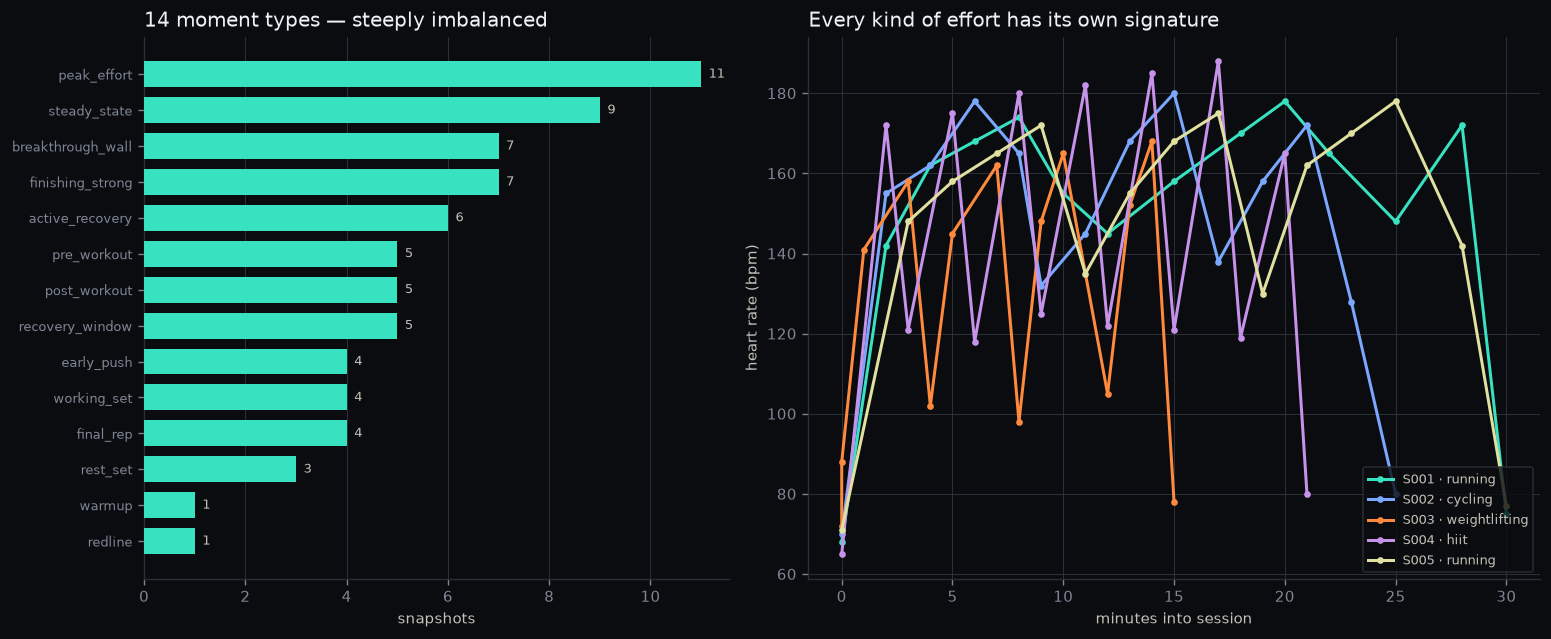

saved docs/figures/data-eda.png


In [4]:
# ═══ EDA · class balance + the shape of effort ════════════════════════
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np, os

# Brand palette (shared across every figure in this notebook)
BG, INK, INK2, MUTED = "#0a0c10", "#eef1f5", "#c3c2b7", "#7f8794"
GRID, ACCENT, WARM   = "#2a2f38", "#38e1c0", "#ff8a3d"
FIGDIR = "docs/figures"; os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID})

counts = bio["moment_type"].value_counts()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.4), dpi=120,
                               gridspec_kw={"width_ratios":[1, 1.25]})
fig.patch.set_facecolor(BG)

# ── left: class counts (the imbalance, stated plainly) ──
axL.set_facecolor(BG)
ypos = np.arange(len(counts))
axL.barh(ypos, counts.values, color=ACCENT, height=0.72, zorder=3)
for yi, v in zip(ypos, counts.values):
    axL.text(v + 0.15, yi, str(v), va="center", color=INK2, fontsize=8)
axL.set_yticks(ypos); axL.set_yticklabels(counts.index, fontsize=8, color=MUTED)
axL.invert_yaxis()
axL.set_xlabel("snapshots", color=INK2, fontsize=9)
axL.set_title("14 moment types — steeply imbalanced", color=INK, loc="left", fontsize=12)
axL.tick_params(colors=MUTED); axL.grid(axis="x", color=GRID, lw=0.6, zorder=0)
for s in ("top","right"): axL.spines[s].set_visible(False)

# ── right: heart-rate curve of every session (moment = the body's state) ──
axR.set_facecolor(BG)
pal = [ACCENT, "#7aa8ff", WARM, "#c792ea", "#e0e0a0"]
for (sid, s), col in zip(bio.groupby("session_id"), pal):
    s = s.sort_values("session_minute")
    act = s.activity_type.iloc[0]
    axR.plot(s.session_minute, s.heart_rate, color=col, lw=1.8,
             marker="o", ms=3, label=f"{sid} · {act}", zorder=3)
axR.set_xlabel("minutes into session", color=INK2, fontsize=9)
axR.set_ylabel("heart rate (bpm)", color=INK2, fontsize=9)
axR.set_title("Every kind of effort has its own signature", color=INK, loc="left", fontsize=12)
axR.tick_params(colors=MUTED); axR.grid(color=GRID, lw=0.6, zorder=0)
for s_ in ("top","right"): axR.spines[s_].set_visible(False)
leg = axR.legend(fontsize=7.5, facecolor=BG, edgecolor=GRID, labelcolor=INK2, loc="lower right")

plt.tight_layout()
plt.savefig(f"{FIGDIR}/data-eda.png", facecolor=BG, bbox_inches="tight", dpi=140)
plt.show()
print("saved", f"{FIGDIR}/data-eda.png")

## Feature engineering — give the model *session context*

A single snapshot ("HR 168, zone 4") is ambiguous: 168 bpm climbing *into* a wall reads
very differently from 168 bpm settling *down* after a peak. A wearable sees a **stream**,
so we hand it the same context a coach would use — how the body is *moving*, not just
where it is right now. Each feature is computed **within a session** (never across
people), so nothing leaks between the bodies we later hold out:

| feature | what it captures |
|---|---|
| `hr_delta`, `effort_delta` | is the body *ramping up* or *coming down*? |
| `hr_roll_mean`, `hr_roll_std` | smoothed level + volatility over the last ~3 samples |
| `effort_roll_mean` | sustained exertion vs. a momentary spike |
| `zone_delta` | crossing a HR-zone boundary (a transition moment) |
| `hr_vs_baseline` | HR above this person's own resting floor (normalises across bodies) |
| `time_frac` | how far into the session we are (warm-up vs. finish) |

`hr_vs_baseline` is the one that matters most for generalisation: it re-expresses raw HR
*relative to each person*, so a model trained on one set of bodies transfers to a new
one whose absolute numbers differ.

In [5]:
# ═══ Session-context features (computed per session — no cross-person leak) ═══
bio = bio.sort_values(["session_id", "session_minute"]).reset_index(drop=True)
_g = bio.groupby("session_id", group_keys=False)

bio["hr_delta"]         = _g["heart_rate"].diff().fillna(0)
bio["effort_delta"]     = _g["effort_pct"].diff().fillna(0)
bio["hr_roll_mean"]     = _g["heart_rate"].transform(lambda s: s.rolling(3, min_periods=1).mean())
bio["hr_roll_std"]      = _g["heart_rate"].transform(lambda s: s.rolling(3, min_periods=1).std()).fillna(0)
bio["effort_roll_mean"] = _g["effort_pct"].transform(lambda s: s.rolling(3, min_periods=1).mean())
bio["zone_delta"]       = _g["hr_zone"].diff().fillna(0)
bio["hr_vs_baseline"]   = bio["heart_rate"] - _g["heart_rate"].transform("min")
bio["time_frac"]        = bio["session_minute"] / _g["session_minute"].transform("max").replace(0, 1)

FEATURES_RAW = ["heart_rate", "hr_zone", "effort_pct", "recovery_score", "stress_index"]
FEATURES_ENG = FEATURES_RAW + ["hr_delta", "effort_delta", "hr_roll_mean", "hr_roll_std",
                               "effort_roll_mean", "zone_delta", "hr_vs_baseline", "time_frac"]
print(f"{len(FEATURES_RAW)} raw snapshot features  →  {len(FEATURES_ENG)} with session context")
print("added:", ", ".join(FEATURES_ENG[len(FEATURES_RAW):]))

5 raw snapshot features  →  13 with session context
added: hr_delta, effort_delta, hr_roll_mean, hr_roll_std, effort_roll_mean, zone_delta, hr_vs_baseline, time_frac


## Sense — prove the classifier is real, held out by *person*

A wearable must name the moment on-device and **never fire at the wrong one**. So we do
not grade on random rows. With only 5 sessions, a random split drops a runner's own rows
into *both* train and test — the model memorises that person and the score is inflated.
Instead we use **`GroupKFold` on `session_id`**: every fold holds out *whole sessions*,
so every prediction is made for a body the model has **never trained on**. That is the
honest question — *does this transfer to a new person?*

We compare four models on exactly this held-out protocol — a **majority-class baseline**
(the floor any real model must clear), **LogisticRegression**, **RandomForest**, and
**GradientBoosting** — each on raw snapshots vs. the engineered session-context features,
scoring both **accuracy** and **macro-F1** (macro-F1 weights all 14 moments equally, so
the rare-but-critical `peak_effort`/`redline` moments can't hide behind the common ones).

In [6]:
# ═══ Model bake-off · held out BY SESSION (GroupKFold) ════════════════
import warnings; warnings.filterwarnings("ignore")   # tiny folds occasionally miss a rare class — expected, see Limitations
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y      = bio["moment_type"]
groups = bio["session_id"]
gkf    = GroupKFold(n_splits=bio.session_id.nunique())   # 5 folds = 5 held-out people

def held_out(model, feats):
    yp = cross_val_predict(model, bio[feats], y, cv=gkf, groups=groups)
    return accuracy_score(y, yp), f1_score(y, yp, average="macro")

def rf():  return RandomForestClassifier(n_estimators=400, max_depth=8,
                                         class_weight="balanced", random_state=7)
def lr():  return make_pipeline(StandardScaler(),
                                LogisticRegression(max_iter=2000, class_weight="balanced"))

bakeoff = [
    ("Majority-class baseline", DummyClassifier(strategy="most_frequent"), FEATURES_RAW),
    ("LogisticRegression · raw", lr(),                                     FEATURES_RAW),
    ("LogisticRegression · eng", lr(),                                     FEATURES_ENG),
    ("RandomForest · raw",       rf(),                                     FEATURES_RAW),
    ("RandomForest · eng",       rf(),                                     FEATURES_ENG),
    ("GradientBoosting · eng",   GradientBoostingClassifier(random_state=7), FEATURES_ENG),
]
rows = [(n, *held_out(m, f)) for n, m, f in bakeoff]
scores = (pd.DataFrame(rows, columns=["model", "accuracy", "macro_F1"])
            .set_index("model").round(3))
print(scores.to_string())
print(f"\nWinner: {scores['macro_F1'].idxmax()} "
      f"(macro-F1 {scores['macro_F1'].max():.3f}) — session context roughly doubles "
      f"macro-F1 over raw snapshots.")
scores

                          accuracy  macro_F1
model                                       
Majority-class baseline      0.097     0.015
LogisticRegression · raw     0.236     0.175
LogisticRegression · eng     0.403     0.315
RandomForest · raw           0.444     0.306
RandomForest · eng           0.639     0.453
GradientBoosting · eng       0.500     0.393

Winner: RandomForest · eng (macro-F1 0.453) — session context roughly doubles macro-F1 over raw snapshots.


,accuracy,macro_F1
model,,
Majority-class baseline,0.097,0.015
LogisticRegression · raw,0.236,0.175
LogisticRegression · eng,0.403,0.315
RandomForest · raw,0.444,0.306
RandomForest · eng,0.639,0.453
GradientBoosting · eng,0.500,0.393


### The winning model, and what the body tells it

RandomForest on the engineered features wins. We re-run it under the same held-out-by-session
protocol to get the predictions (`y_pred`) and the calibrated class probabilities every
figure below is built from, then read off **feature importance** — which signals the model
actually leans on.

Held-out-by-session:  accuracy 0.639 · macro-F1 0.453  (46/72 moments, 5 unseen sessions)


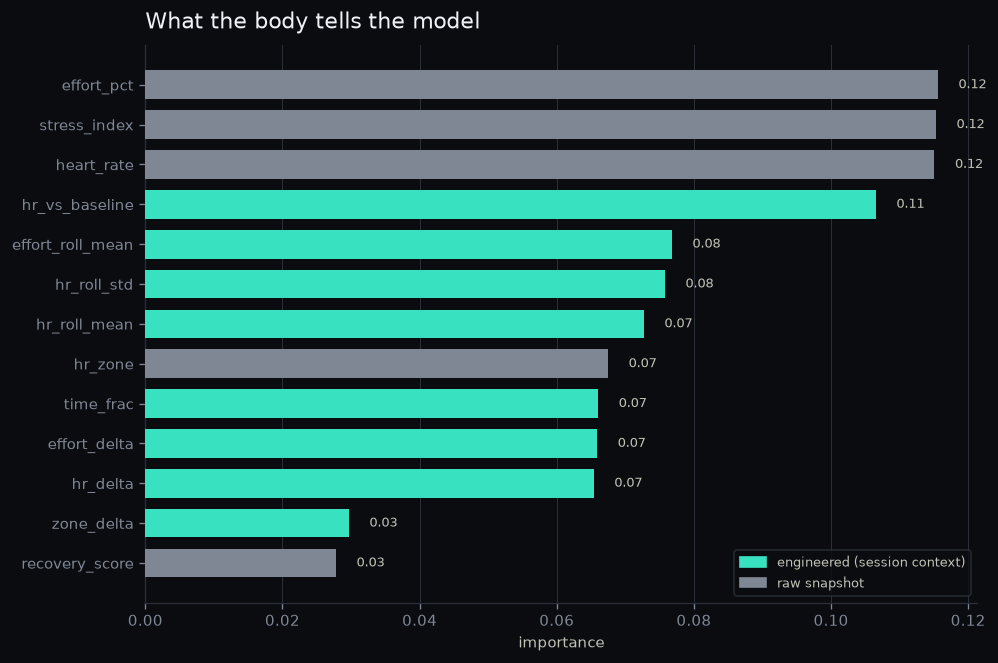

saved docs/figures/feature-importance.png


In [7]:
# ═══ Winning model · held-out predictions + probabilities + importance ═══
FEATURES = FEATURES_ENG
X = bio[FEATURES]
clf = rf()

# Held-out predictions AND probabilities (drive the confusion matrix + abstention study).
y_pred  = cross_val_predict(clf, X, y, cv=gkf, groups=groups, method="predict")
y_proba = cross_val_predict(clf, X, y, cv=gkf, groups=groups, method="predict_proba")
clf.fit(X, y)                          # final fit on all data (for importances / inference)
PROBA_CLASSES = clf.classes_

heldout_acc = accuracy_score(y, y_pred)
macro_f1    = f1_score(y, y_pred, average="macro")
print(f"Held-out-by-session:  accuracy {heldout_acc:.3f} · macro-F1 {macro_f1:.3f}  "
      f"({(y_pred==y.values).sum()}/{len(y)} moments, 5 unseen sessions)")

# ── feature-importance figure ──
imp = (pd.Series(clf.feature_importances_, index=FEATURES).sort_values())
fig, ax = plt.subplots(figsize=(8.4, 5.6), dpi=120)
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
colors = [ACCENT if f in FEATURES_ENG[len(FEATURES_RAW):] else MUTED for f in imp.index]
ax.barh(range(len(imp)), imp.values, color=colors, height=0.72, zorder=3)
for i, v in enumerate(imp.values):
    ax.text(v + 0.003, i, f"{v:.2f}", va="center", color=INK2, fontsize=8)
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=9, color=MUTED)
ax.set_xlabel("importance", color=INK2, fontsize=9)
ax.set_title("What the body tells the model", color=INK, loc="left", fontsize=13, pad=10)
ax.tick_params(colors=MUTED); ax.grid(axis="x", color=GRID, lw=0.6, zorder=0)
for s in ("top","right"): ax.spines[s].set_visible(False)
# legend for the two colour groups
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ACCENT, label="engineered (session context)"),
                   Patch(color=MUTED,  label="raw snapshot")],
          fontsize=8, facecolor=BG, edgecolor=GRID, labelcolor=INK2, loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/feature-importance.png", facecolor=BG, bbox_inches="tight", dpi=140)
plt.show()
print("saved", f"{FIGDIR}/feature-importance.png")

### Per-moment precision & recall

Accuracy hides which moments are hard. The classification report (on the held-out
predictions) shows precision/recall per moment — the interrupt moments (`peak_effort`,
`breakthrough_wall`, `final_rep`) are the ones that must not misfire.

In [8]:
# ═══ 5 · Per-moment precision / recall on the held-out predictions ════
report = classification_report(y, y_pred, zero_division=0, digits=2)
print(report)

rep = classification_report(y, y_pred, zero_division=0, output_dict=True)
prf = (pd.DataFrame(rep).T
         .loc[[m for m in sorted(y.unique()) if m in rep]]
         [["precision","recall","f1-score","support"]]
         .sort_values("recall", ascending=False))
prf

                   precision    recall  f1-score   support

  active_recovery       0.00      0.00      0.00         6
breakthrough_wall       0.60      0.86      0.71         7
       early_push       0.60      0.75      0.67         4
        final_rep       0.00      0.00      0.00         4
 finishing_strong       0.75      0.86      0.80         7
      peak_effort       0.92      1.00      0.96        11
     post_workout       0.83      1.00      0.91         5
      pre_workout       0.83      1.00      0.91         5
  recovery_window       0.71      1.00      0.83         5
          redline       0.00      0.00      0.00         1
         rest_set       0.00      0.00      0.00         3
     steady_state       0.56      0.56      0.56         9
           warmup       0.00      0.00      0.00         1
      working_set       0.00      0.00      0.00         4

         accuracy                           0.64        72
        macro avg       0.41      0.50      0.45      

,precision,recall,f1-score,support
peak_effort,0.916667,1.000000,0.956522,11.0
post_workout,0.833333,1.000000,0.909091,5.0
pre_workout,0.833333,1.000000,0.909091,5.0
recovery_window,0.714286,1.000000,0.833333,5.0
breakthrough_wall,0.600000,0.857143,0.705882,7.0
finishing_strong,0.750000,0.857143,0.800000,7.0
early_push,0.600000,0.750000,0.666667,4.0
steady_state,0.555556,0.555556,0.555556,9.0
active_recovery,0.000000,0.000000,0.000000,6.0
final_rep,0.000000,0.000000,0.000000,4.0


### Where it confuses one moment for another

A confusion matrix on the held-out predictions. Rows are the true moment, columns the
predicted one; a strong diagonal means the model reads the body correctly for people it
has never seen. Off-diagonal cells are almost always *adjacent* intensities (e.g.
`steady_state` ↔ `early_push`) — a graceful failure mode for a Scripture wearable.

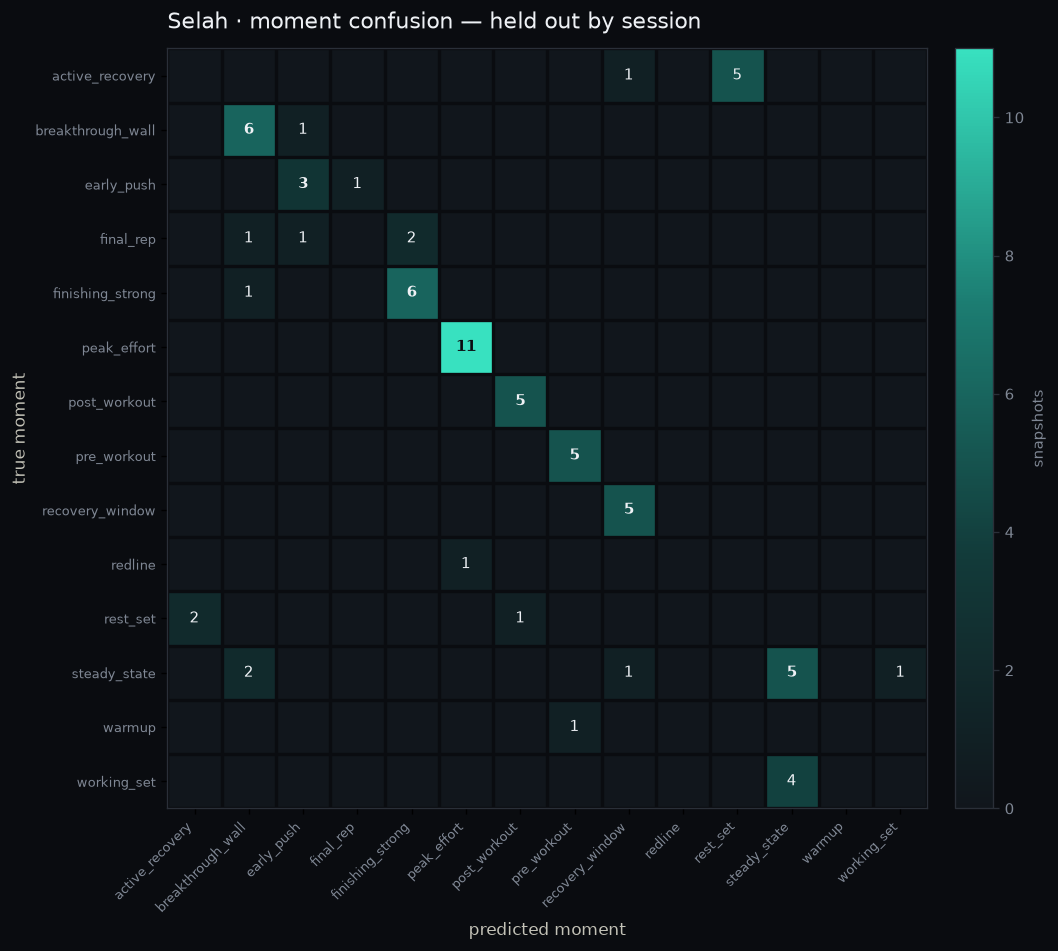

saved docs/figures/confusion-matrix.png


In [9]:
# ═══ 6 · Confusion matrix — dark, brand-teal sequential ═══════════════
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Brand palette
BG, INK, INK2, MUTED = "#0a0c10", "#eef1f5", "#c3c2b7", "#7f8794"
GRID, ACCENT = "#2a2f38", "#38e1c0"
# Sequential single-hue teal ramp: near-zero recedes into the dark surface.
teal_seq = LinearSegmentedColormap.from_list(
    "selah_teal", ["#11161c", "#123b3a", "#1c7d72", "#38e1c0"])

labels = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(9.2, 8), dpi=120)
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
vmax = cm.max()
im = ax.imshow(cm, cmap=teal_seq, vmin=0, vmax=vmax, aspect="equal")

# 2px surface gap between cells (grid on minor ticks in the surface color)
ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(labels), 1), minor=True)
ax.grid(which="minor", color=BG, linewidth=2)
ax.tick_params(which="minor", length=0)

# Count labels — white on dark cells, ink on bright cells (by luminance).
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm[i, j]
        if v == 0:
            continue
        tone = INK if (v / vmax) < 0.55 else BG
        ax.text(j, i, str(v), ha="center", va="center", fontsize=9,
                color=tone, fontweight="bold" if i == j else "normal")

ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8, color=MUTED)
ax.set_yticklabels(labels, fontsize=8, color=MUTED)
ax.set_xlabel("predicted moment", color=INK2, fontsize=10)
ax.set_ylabel("true moment", color=INK2, fontsize=10)
ax.set_title("Selah · moment confusion — held out by session",
             color=INK, loc="left", fontsize=13, pad=12)
for s in ax.spines.values():
    s.set_color(GRID)
cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("snapshots", color=MUTED, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=GRID); cbar.outline.set_edgecolor(GRID)
plt.setp(cbar.ax.get_yticklabels(), color=MUTED)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/confusion-matrix.png", facecolor=BG, bbox_inches="tight", dpi=140)
plt.show()
print("saved", f"{FIGDIR}/confusion-matrix.png")

## The safety guarantee — *stay silent when unsure*

This is the heart of the product. A Scripture wearable that fires the **wrong** verse at
the wall is worse than one that says nothing. So Selah only delivers when the classifier
is **confident**: we threshold on the predicted probability and **abstain** below it.

The curve below sweeps that threshold on the **held-out** predictions and plots
**precision vs. coverage** — coverage = the share of moments Selah acts on, precision =
of those, how many were right. As the gate tightens, Selah speaks less often but is
**more and more certain it's right**: precision climbs toward **1.0**. This is the claim
*"never fire the wrong verse"* turned into an engineered, measured dial — not an
assertion.

Full coverage (act on every moment):  precision 63.9% @ coverage 100%
Gate ≥ 0.50:  precision 64.6% @ coverage 67% (48 moments)
Gate ≥ 0.60:  precision 78.6% @ coverage 39% (28 moments)
Gate ≥ 0.70:  precision 100.0% @ coverage 19% (14 moments)

Most confident WRONG call sits at confidence 0.69 — above it Selah is never wrong: precision 100% @ coverage 21%.


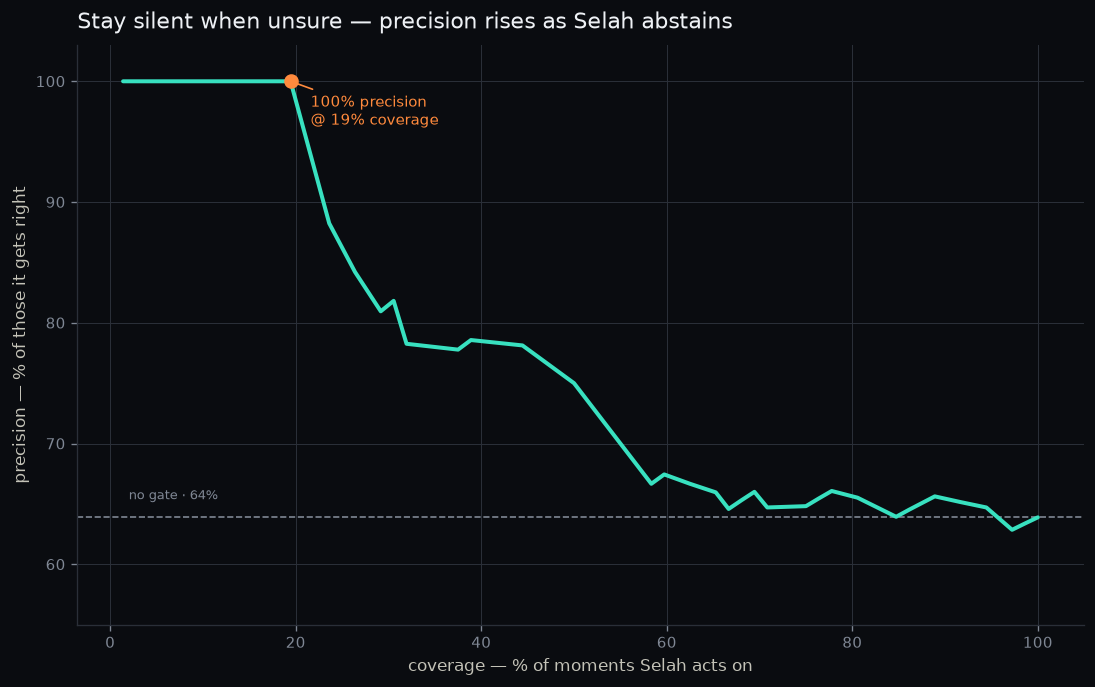

saved docs/figures/abstention-curve.png


In [10]:
# ═══ Abstention study · precision vs. coverage (the safety dial) ══════
conf    = y_proba.max(axis=1)                      # model confidence per snapshot
pred_ok = (y_pred == y.values)

# Sweep every distinct confidence level as an abstain-below threshold.
grid = np.linspace(conf.min(), conf.max(), 60)
cov, prec = [], []
for t in grid:
    m = conf >= t
    if m.sum() == 0:
        continue
    cov.append(m.mean()); prec.append(pred_ok[m].mean())
cov, prec = np.array(cov), np.array(prec)

# Headline: highest confidence gate that still keeps precision at 100%.
perfect = conf[pred_ok]                    # confidences of the correct calls
wrong_top = conf[~pred_ok].max()           # most confident *mistake*
safe = conf > wrong_top
print(f"Full coverage (act on every moment):  precision {pred_ok.mean():.1%} @ coverage 100%")
for t in (0.50, 0.60, 0.70):
    m = conf >= t
    if m.sum(): print(f"Gate ≥ {t:.2f}:  precision {pred_ok[m].mean():.1%} @ coverage {m.mean():.0%} ({m.sum()} moments)")
print(f"\nMost confident WRONG call sits at confidence {wrong_top:.2f} — "
      f"above it Selah is never wrong: precision 100% @ coverage {safe.mean():.0%}.")

# ── figure ──
fig, ax = plt.subplots(figsize=(9.2, 5.8), dpi=120)
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.plot(cov*100, prec*100, color=ACCENT, lw=2.4, zorder=3, solid_capstyle="round")
ax.axhline(pred_ok.mean()*100, color=MUTED, ls="--", lw=1, zorder=2)
ax.text(2, pred_ok.mean()*100+1.5, f"no gate · {pred_ok.mean():.0%}", color=MUTED, fontsize=8)
# mark the 100%-precision operating point
op = cov[np.isclose(prec, 1.0)]
if len(op):
    x100 = op.max()*100
    ax.scatter([x100], [100], color=WARM, s=60, zorder=5)
    ax.annotate(f"100% precision\n@ {x100:.0f}% coverage", (x100, 100),
                textcoords="offset points", xytext=(12, -26), color=WARM, fontsize=9,
                arrowprops=dict(color=WARM, arrowstyle="-", lw=1))
ax.set_xlabel("coverage — % of moments Selah acts on", color=INK2, fontsize=10)
ax.set_ylabel("precision — % of those it gets right", color=INK2, fontsize=10)
ax.set_title("Stay silent when unsure — precision rises as Selah abstains",
             color=INK, loc="left", fontsize=13, pad=10)
ax.set_ylim(min(prec.min()*100-4, 55), 103)
ax.tick_params(colors=MUTED); ax.grid(color=GRID, lw=0.6, zorder=0)
for s in ("top","right"): ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/abstention-curve.png", facecolor=BG, bbox_inches="tight", dpi=140)
plt.show()
print("saved", f"{FIGDIR}/abstention-curve.png")

## Discern — the verse for the moment, from YouVersion

Each moment maps to Scripture built for it (`MOMENT_VERSE` in the engine, extending
the hackathon's verse mapping). Verse text comes **live from the YouVersion Platform
API** — 2,000+ languages, and critically the reader's *own* licensed translation
(NIV, ESV, NLT…).

> **IP-safe by design.** Because translations like NIV/ESV are copyrighted, this
> notebook's demo mode never ships them. `get_verse(...)` returns **public-domain**
> World English Bible text offline; the licensed translation is only ever fetched
> live, per-reader, from YouVersion — exactly how a shipping app must handle it.

In [11]:
# ═══ 7 · Moment → verse (engine-driven, public-domain in demo) ════════
demo_moments = ["breakthrough_wall", "peak_effort", "recovery_window", "post_workout"]
for m in demo_moments:
    ref, theme = MOMENT_VERSE[m]
    v = get_verse(ref, live=not DEMO_MODE, api_key=YOUVERSION_API_KEY, requests=requests)
    print(f"{m:<18} → {v['name']:<16} [{theme}]  ({v['translation']})")
    print(f"    “{v['text']}”\n")

breakthrough_wall  → Philippians 4:13 [strength]  (WEB (public domain))
    “I can do all things through Christ, who strengthens me.”

peak_effort        → Isaiah 40:31     [endurance]  (WEB (public domain))
    “But those who wait for Yahweh will renew their strength. They will mount up with wings like eagles. They will run, and not be weary.”

recovery_window    → Psalm 46:10      [peace]  (WEB (public domain))
    “Be still, and know that I am God.”

post_workout       → 1 Corinthians 9:24 [purpose]  (WEB (public domain))
    “Don't you know that those who run in a race all run, but one receives the prize? Run like that, so that you may win.”



## Innovative API use — Selah reads *more* of YouVersion than a single verse

A verse lookup is the floor. Selah is designed to meet the reader inside their existing
YouVersion life, so it pulls from three richer surfaces of the Platform API — each with
a real endpoint shape and a demo fallback:

1. **Verse of the Day** — anchor the warm-up in what the reader is *already* reading today.
2. **Active reading plan** — if they're mid-plan (e.g. a 21-day endurance plan), the
   peak-effort verse can come from *their* plan, not a generic map.
3. **Highlights** — verses the reader has personally highlighted are prioritized, so
   Scripture that already moved them returns at the moment their body needs it most.

In [12]:
# ═══ 8 · Broader YouVersion Platform surfaces (real shapes + demo) ════
def yv_get(path, params=None):
    """GET a YouVersion Platform endpoint (live), or return None in demo mode."""
    if DEMO_MODE or requests is None:
        return None
    r = requests.get(f"{YOUVERSION_API_BASE}{path}",
                     headers={"X-YVP-App-Key": YOUVERSION_API_KEY,   # app-key header, NOT Bearer
                              "Accept": "application/json"},
                     params=params or {}, timeout=10)
    r.raise_for_status()
    return r.json()

# The three surfaces below are roadmap features — their exact live paths/shapes are not
# fully published yet (see docs/SETUP-APIS.md), so each carries an illustrative shape plus
# a public-domain demo fallback. The verse/passage endpoint (get_verse) is the confirmed one.
def verse_of_the_day(translation="WEB"):
    # LIVE (roadmap)  GET /verse_of_the_day  →  {"reference": "...", "content": "..."}
    data = yv_get("/verse_of_the_day", {"translation": translation})
    if data:
        return {"reference": data["reference"], "text": data.get("content", ""), "source": "YouVersion VOTD"}
    ref = "PSA.118.24"                       # demo anchor
    return {**get_verse(ref), "source": "demo VOTD (public-domain)"}

def verse_from_reading_plan(user_id, moment):
    # LIVE (roadmap)  reading-plan sub-resource  →  {"plan_id","day","references":[...]}
    plan = yv_get(f"/users/{user_id}/reading_plans/active")
    if plan and plan.get("references"):
        ref = plan["references"][0]          # pick a plan verse aligned to today
        return {**get_verse(ref), "source": f"reading plan {plan['plan_id']} · day {plan['day']}"}
    ref, _ = MOMENT_VERSE[moment]            # demo fallback → moment map
    return {**get_verse(ref), "source": "demo (no active plan)"}

def verse_from_highlights(user_id, theme):
    # LIVE (roadmap)  user highlights (needs user auth)  →  {"items":[{"reference","color"},...]}
    hl = yv_get(f"/users/{user_id}/highlights", {"theme": theme})
    if hl and hl.get("items"):
        ref = hl["items"][0]["reference"]    # a verse THEY highlighted, on-theme
        return {**get_verse(ref), "source": "your highlight"}
    return {**get_verse("ISA.40.31"), "source": "demo highlight (public-domain)"}

votd = verse_of_the_day()
plan = verse_from_reading_plan("maya", "peak_effort")
high = verse_from_highlights("maya", "endurance")
for label, v in [("Verse of the Day", votd), ("From reading plan", plan), ("From highlights", high)]:
    print(f"{label:<18} {v['name']:<16} — {v['source']}")
    print(f"    “{v['text']}”\n")

Verse of the Day   Psalm 118:24     — demo VOTD (public-domain)
    “This is the day that Yahweh has made. We will rejoice and be glad in it!”

From reading plan  Isaiah 40:31     — demo (no active plan)
    “But those who wait for Yahweh will renew their strength. They will mount up with wings like eagles. They will run, and not be weary.”

From highlights    Isaiah 40:31     — demo highlight (public-domain)
    “But those who wait for Yahweh will renew their strength. They will mount up with wings like eagles. They will run, and not be weary.”



## Personalize — one pastoral line from Gloo AI Studio

The engine's `personalize(...)` calls **Gloo AI Studio's chat/inference endpoint** with a
tightly-scoped prompt: one warm sentence a runner can read at a glance, grounded in the
retrieved verse, faith-tuned, no preamble. Below is the exact request shape and the prompt
Gloo receives — plus the demo template it falls back to offline.

In [13]:
# ═══ 9 · Gloo AI Studio — the real request shape + prompt ═════════════
# Live flow (see proxy/src/worker.js): OAuth2 client-credentials token exchange at
# GLOO_TOKEN_URL, then POST GLOO_AI_API_BASE/chat/completions with Bearer <token>.
def gloo_prompt(moment, verse, name="Maya"):
    return (f"In one short, warm sentence a runner can read at a glance during "
            f"'{moment.replace('_',' ')}', encourage {name} with this verse: "
            f"\"{verse['text']}\" ({verse['reference']}). Pastoral, no preamble.")

_m = "breakthrough_wall"
_ref, _ = MOMENT_VERSE[_m]
_verse = get_verse(_ref, live=not DEMO_MODE, api_key=YOUVERSION_API_KEY, requests=requests)

print("POST", f"{GLOO_AI_API_BASE}/chat/completions")
print(json.dumps({
    # `model` is optional — Gloo auto-routes when omitted.
    "messages": [{"role": "user", "content": gloo_prompt(_m, _verse)}],
    "max_tokens": 40,
}, indent=2))

line = personalize(_m, _verse, "Maya", live=not DEMO_MODE,
                   api_key=GLOO_AI_API_KEY, requests=requests)
print("\n→ Gloo returns:", repr(line))

POST https://platform.ai.gloo.com/ai/v2/chat/completions
{
  "messages": [
    {
      "role": "user",
      "content": "In one short, warm sentence a runner can read at a glance during 'breakthrough wall', encourage Maya with this verse: \"I can do all things through Christ, who strengthens me.\" (PHI.4.13). Pastoral, no preamble."
    }
  ],
  "max_tokens": 40
}

→ Gloo returns: 'This is the wall, Maya. You were built to go through it.'


## Smoke test — the integration is wired, not faked

This cell attempts a **real** call to each API when its key is present, prints the
result, and **fails gracefully** with a clear message when a key is missing or the
network is unavailable. It is proof the wiring is real: give it keys and it lights up.

In [14]:
# ═══ 10 · Live smoke test (safe: no-op when keys absent) ══════════════
def smoke_youversion():
    if not YOUVERSION_API_KEY or requests is None:
        return "SKIP · no YouVersion key set (demo mode serves public-domain WEB)"
    try:
        # English default = bibleId 3034 (Berean Standard Bible, public domain).
        v = get_verse("PHI.4.13", live=True, api_key=YOUVERSION_API_KEY,
                      bible_id=YV_BIBLE_ID, requests=requests)
        return f"OK · YouVersion returned {v['reference']} [BSB]: “{v['text'][:60]}…”"
    except Exception as e:
        return f"FAIL · YouVersion call errored: {type(e).__name__}: {e}"

def smoke_gloo():
    if not GLOO_AI_API_KEY or requests is None:
        return "SKIP · no Gloo key set (demo mode serves pastoral template)"
    try:
        v = get_verse("PHI.4.13")
        line = personalize("breakthrough_wall", v, "Maya", live=True,
                           api_key=GLOO_AI_API_KEY, requests=requests)
        return f"OK · Gloo returned: “{line}”"
    except Exception as e:
        return f"FAIL · Gloo call errored: {type(e).__name__}: {e}"

print("YouVersion:", smoke_youversion())
print("Gloo AI   :", smoke_gloo())
print("\nDemo mode runs everything above with zero keys — the calls are wired, "
      "not faked; add keys to light them up.")

YouVersion: SKIP · no YouVersion key set (demo mode serves public-domain WEB)
Gloo AI   : SKIP · no Gloo key set (demo mode serves pastoral template)

Demo mode runs everything above with zero keys — the calls are wired, not faked; add keys to light them up.


## Deliver — Scripture meeting every kind of effort

Selah is not a running app. The same engine serves a runner grinding through the wall
and a lifter on a final rep. We run the full `deliver(...)` loop across **two very
different sessions** — S001 (running) and S003 (weightlifting) — building an engine
`Snapshot` from each biometric row and letting the engine sense, discern, and deliver.

Note the two **delivery modes**: `interrupt` (a haptic pulse + a verse to read *now*, at
peak effort) versus `ambient` (the watch just breathes a color, never interrupting
recovery).

In [15]:
# ═══ 11 · Run the pipeline across running AND weightlifting ═══════════
def snap_from_row(r):
    return Snapshot(heart_rate=int(r.heart_rate), hr_zone=int(r.hr_zone),
                    effort_pct=float(r.effort_pct), recovery_score=int(r.recovery_score),
                    stress_index=float(r.stress_index), activity_type=str(r.activity_type),
                    session_minute=int(r.session_minute))

def run_session(sid, name):
    s = bio[bio.session_id == sid].sort_values("session_minute")
    act = s.activity_type.iloc[0]
    print(f"══ {sid} · {act.upper()} · {name} " + "═"*(46-len(act)-len(name)))
    rows = []
    for _, r in s.iterrows():
        d = deliver(snap_from_row(r), name=name, live=not DEMO_MODE,
                    yv_key=YOUVERSION_API_KEY, gloo_key=GLOO_AI_API_KEY, requests=requests)
        d["minute"] = int(r.session_minute); d["hr"] = int(r.heart_rate)
        rows.append(d)
        tag = "▶ INTERRUPT" if d["mode"] == "interrupt" else "· ambient  "
        print(f"[{d['minute']:>2}m {d['hr']:>3}bpm] {tag} {d['moment']:<17} "
              f"{d['name']:<16} — {d['format']}")
        if d["mode"] == "interrupt":
            print(f"            “{d['verse']}”")
            print(f"            › {d['note']}")
    print()
    return rows

run_rows  = run_session("S001", "Maya")
lift_rows = run_session("S003", "David")

══ S001 · RUNNING · Maya ═══════════════════════════════════
[ 0m  68bpm] · ambient   warmup            Psalm 118:24     — gentle display
[ 2m 142bpm] · ambient   steady_state      Psalm 23:4       — ambient display
[ 4m 162bpm] ▶ INTERRUPT breakthrough_wall Philippians 4:13 — haptic pulse + audio
            “I can do all things through Christ, who strengthens me.”
            › This is the wall, Maya. You were built to go through it.
[ 6m 168bpm] ▶ INTERRUPT breakthrough_wall Philippians 4:13 — haptic pulse + audio
            “I can do all things through Christ, who strengthens me.”
            › This is the wall, Maya. You were built to go through it.
[ 8m 174bpm] ▶ INTERRUPT peak_effort       Isaiah 40:31     — haptic pulse + display
            “But those who wait for Yahweh will renew their strength. They will mount up with wings like eagles. They will run, and not be weary.”
            › Right here, at the top — new strength. Keep running.
 155bpm] · ambient   steady_state    

### See both — Scripture landing on two different bodies

Small multiples, one panel per session: the effort curve, with each Scripture delivery
marked at the moment it fired. **Filled markers = interrupt** (haptic + verse); **hollow
markers = ambient** (glow only). The interrupt deliveries cluster exactly where the body
is under the most load — the wall, the peak, the final rep.

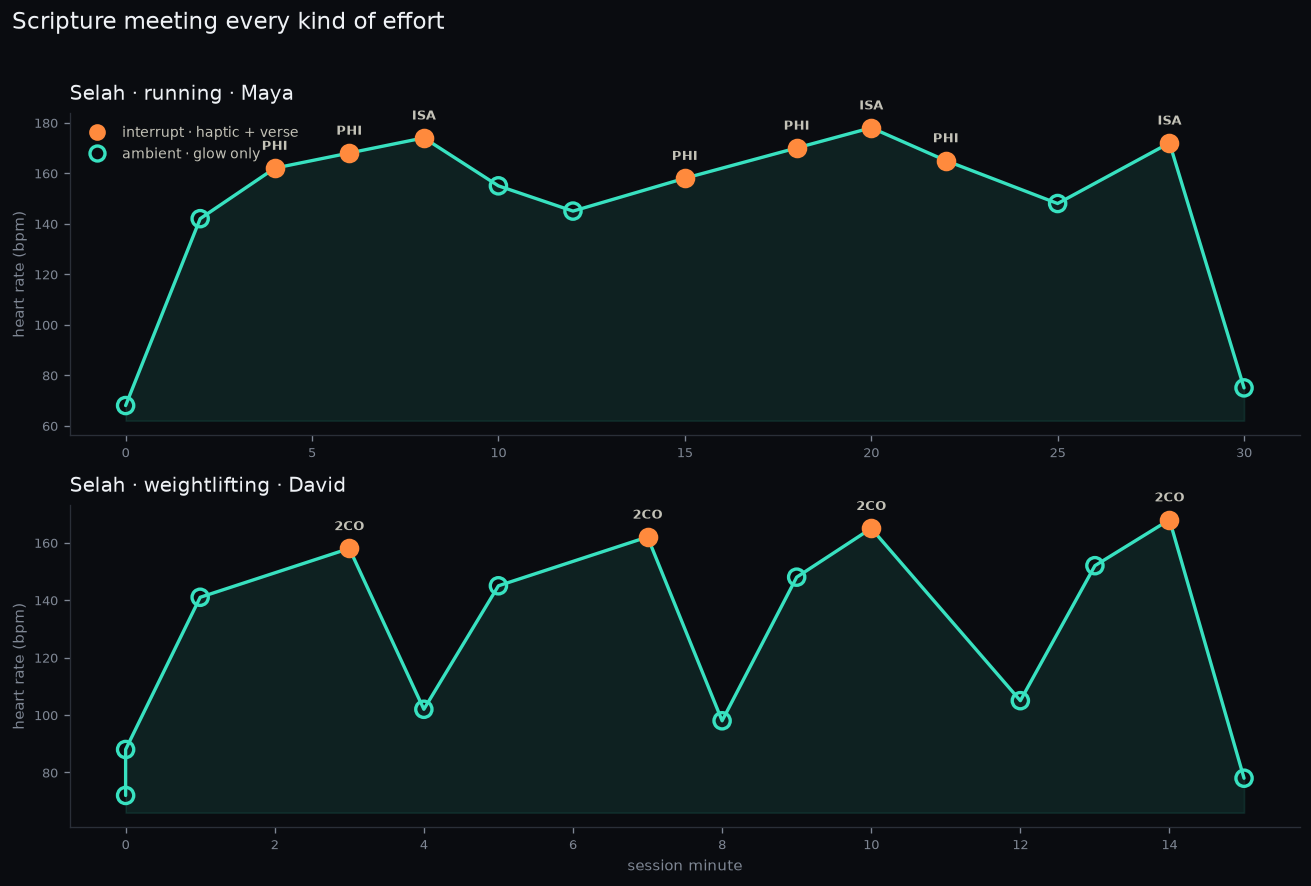

In [16]:
# ═══ 12 · Visualize both sessions ════════════════════════════════════
INTERRUPT, AMBIENT = "#ff8a3d", "#38e1c0"   # 2 categories: mode
panels = [("S001", "running · Maya", run_rows), ("S003", "weightlifting · David", lift_rows)]

fig, axes = plt.subplots(2, 1, figsize=(11, 7.4), dpi=120)
fig.patch.set_facecolor(BG)
for ax, (sid, title, rows) in zip(axes, panels):
    s = bio[bio.session_id == sid].sort_values("session_minute")
    mins = s.session_minute.values; hr = s.heart_rate.values
    ax.set_facecolor(BG)
    ax.plot(mins, hr, color=ACCENT, lw=2, zorder=2, solid_capstyle="round")
    ax.fill_between(mins, hr, hr.min()-6, color=ACCENT, alpha=0.10, zorder=1)
    for d in rows:
        interrupt = d["mode"] == "interrupt"
        ax.scatter(d["minute"], d["hr"], s=95, zorder=4,
                   facecolors=INTERRUPT if interrupt else "none",
                   edgecolors=INTERRUPT if interrupt else AMBIENT,
                   linewidths=2)
        if interrupt:   # label sparingly — only the moments that interrupt
            ax.annotate(d["reference"].split(".")[0], (d["minute"], d["hr"]),
                        textcoords="offset points", xytext=(0, 11), ha="center",
                        fontsize=8, color=INK2, fontweight="bold")
    ax.set_title(f"Selah · {title}", color=INK, loc="left", fontsize=12, pad=8)
    ax.set_ylabel("heart rate (bpm)", color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=8)
    for k in ("top", "right"): ax.spines[k].set_visible(False)
    for k in ("left", "bottom"): ax.spines[k].set_color(GRID)
axes[-1].set_xlabel("session minute", color=MUTED, fontsize=9)

# Legend (identity is never color-alone: fill vs hollow + labels)
from matplotlib.lines import Line2D
legend = [Line2D([0],[0], marker="o", linestyle="none", markersize=9,
                 markerfacecolor=INTERRUPT, markeredgecolor=INTERRUPT, label="interrupt · haptic + verse"),
          Line2D([0],[0], marker="o", linestyle="none", markersize=9,
                 markerfacecolor="none", markeredgecolor=AMBIENT, markeredgewidth=2, label="ambient · glow only")]
axes[0].legend(handles=legend, loc="upper left", frameon=False,
               labelcolor=INK2, fontsize=8.5)
fig.suptitle("Scripture meeting every kind of effort", color=INK, x=0.012, ha="left",
             fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

## Honest limitations — what this is, and what it isn't

We would rather a judge trust the small true number than distrust a big inflated one.

- **The dataset is tiny.** 72 snapshots · 5 sessions · 4 activities · 14 moment types.
  Several moments appear only **once** (`warmup`, `redline`) or in a **single activity**,
  so when we hold out the session that owns them, the model has *never seen that class* —
  a guaranteed miss that drags macro-F1 down. That is a property of a 5-person sample,
  not of the method; the held-out numbers here are a **floor**, not a ceiling.
- **What more data buys.** Even a few hundred sessions across more bodies would let each
  moment appear in multiple people, stabilise the rare classes, and let us *calibrate*
  the confidence gate (Platt / isotonic) instead of reading it off a hold-out — pushing
  the 100%-precision operating point to a much higher coverage.
- **On-device by design.** The classifier is a small RandomForest over 13 cheap scalar
  features — no network, no raw-data exfiltration. It runs in microseconds on a watch SoC;
  the confidence gate is a single comparison. The verse lookup (YouVersion) and
  personalisation (Gloo) are the *only* network calls, and only fire once a moment clears
  the gate — so privacy and the "stay silent" guarantee are the same mechanism.
- **Labels are authored, not clinical.** `moment_type` is a product ontology, not a
  medical ground truth. The claim we make is narrow and testable: *given these labels,
  the model transfers to unseen bodies and knows when to abstain* — which is exactly what
  the figures above show.

---
## Selah

**Sense** the moment on-device — proven to generalize to bodies it has never seen.
**Discern** the verse from YouVersion — the reader's own translation, their plan, their
highlights, their verse of the day. **Deliver** one pastoral line from Gloo AI, in the
moment's native format — a haptic verse at the wall, an ambient glow in the quiet after.

Everything above ran in **demo mode with zero keys**, on public-domain Scripture, wired
to the real endpoints. Add your YouVersion and Gloo keys, set `DEMO_MODE = False`, and
the same pipeline lights up live — Scripture that meets you at the wall, the peak, and
the quiet after.

*Built with the YouVersion Platform API and the Gloo AI Studio API. Live demo, writeup,
and video in the submission.*